# GMIC — CMMD2022 Rapor (Parca 10)

Iki sey uretir:

1. **Vaka gorselleri** — makalenin Sekil 4'unun karsiligi: ham girdi, benign ve malign saliency
   map'ler, Algoritma 1'in sectigi 6 ROI ve her yamanin dikkat agirligi. Tek GPU gerektiren
   adim bu (6 meme x 2 view, birkac dakika).
2. **Tek dosyalik HTML rapor** — tum figurler base64 gomulu, disariya bagimlilik yok.

Model tanimlari **kopyalanmiyor**: `gmic_cmmd_egitim.ipynb`'deki hucrelerden okunup calistiriliyor,
boylece mimari tek kaynakta kaliyor (Parca 2'deki `hazir/onisleme.py` mantiginin aynisi).

In [1]:
import base64
import json
import os
import sys
from datetime import date
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

ORTAM = 'colab' if os.path.isdir('/content') else 'yerel'
if ORTAM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

KOK = Path('/content/drive/MyDrive/multiple_instance_classifier' if ORTAM == 'colab'
           else Path.cwd())
HAZIR_DIR = Path('/content/hazir') if Path('/content/hazir').exists() else KOK / 'hazir'
RAPOR_DIR = KOK / 'rapor'
FIG_DIR = RAPOR_DIR / 'figurler'
DEG_DIR = KOK / 'degerlendirme'
FIG_DIR.mkdir(parents=True, exist_ok=True)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

with open(HAZIR_DIR / 'config.json', encoding='utf-8') as f:
    VERI_CFG = json.load(f)
GLOBAL_SIZE = tuple(VERI_CFG['GLOBAL_SIZE'])
PATCH_SIZE, K, ESIK, SEED = (VERI_CFG['PATCH_SIZE'], VERI_CFG['K'],
                             VERI_CFG['ESIK'], VERI_CFG['SEED'])

sys.path.insert(0, str(HAZIR_DIR))
from onisleme import pencere_al, z_score

# --- model tanimlarini egitim notebook'undan al (kopyalama yok, tek kaynak) ---
# Not: VSCode + Colab kernel kurulumunda .ipynb dosyalari yerelde durur, kernel onlari goremez.
# Bu yuzden once birkac yerde araniyor, bulunamazsa bir kez yuklenip Drive'a kaydediliyor.
ADAY_NB = [KOK / 'gmic_cmmd_egitim.ipynb',
           Path.cwd() / 'gmic_cmmd_egitim.ipynb',
           Path('/content/gmic_cmmd_egitim.ipynb')]
EGITIM_NB = next((p for p in ADAY_NB if p.exists()), None)

if EGITIM_NB is None and ORTAM == 'colab':
    print('gmic_cmmd_egitim.ipynb bulunamadi. Yerel kopyanizi secin (bir kez; Drive\'a kaydedilir).')
    from google.colab import files
    _yuklenen = files.upload()
    _ad = next(a for a in _yuklenen if a.endswith('.ipynb'))
    EGITIM_NB = KOK / 'gmic_cmmd_egitim.ipynb'
    EGITIM_NB.write_bytes(_yuklenen[_ad])
    print(f'kaydedildi: {EGITIM_NB}')

assert EGITIM_NB is not None and EGITIM_NB.exists(), (
    'gmic_cmmd_egitim.ipynb bulunamadi. Model tanimlari oradan okunuyor; '
    f'dosyayi {KOK} altina kopyalayin.')

ISARETLER = ['class BasicBlockV2', 'def f_agg', 'def retrieve_roi',
             'class LocalNetwork', 'class GMIC']
_nb = json.loads(EGITIM_NB.read_text(encoding='utf-8'))
_alinan = []
for _i, _c in enumerate(_nb['cells']):
    if _c['cell_type'] != 'code':
        continue
    _s = ''.join(_c['source'])
    if any(m in _s for m in ISARETLER):
        exec(compile('\n'.join(l for l in _s.split('\n') if not l.strip().startswith('!')),
                     f'<egitim nb hucre {_i}>', 'exec'), globals())
        _alinan.append(_i)
assert len(_alinan) == len(ISARETLER), f'{_alinan} -- beklenen {len(ISARETLER)} hucre'
print(f'model tanimlari {EGITIM_NB.name} hucrelerinden alindi: {_alinan}')
print(f'  kaynak: {EGITIM_NB}')

manifest = pd.read_csv(HAZIR_DIR / 'manifest.csv')
with open(HAZIR_DIR / 'eval_cases.json', encoding='utf-8') as f:
    VAKALAR = json.load(f)
print(f'ortam {ORTAM} | device {DEVICE} | {GLOBAL_SIZE} | {len(VAKALAR)} ornek vaka')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
model tanimlari gmic_cmmd_egitim.ipynb hucrelerinden alindi: [16, 17, 24, 25, 26]
  kaynak: /content/drive/MyDrive/multiple_instance_classifier/gmic_cmmd_egitim.ipynb
ortam colab | device cuda | (2304, 1280) | 6 ornek vaka


In [2]:
RAPOR_DENEY = 'gmic'          # vaka gorselleri tam model ile uretiliyor
CKPT = KOK / RAPOR_DENEY / 'checkpoints' / 'best.pt'
assert CKPT.exists(), f'{CKPT} yok -- once Parca 8 kosmali'

_ck = torch.load(CKPT, map_location=DEVICE, weights_only=False)
HP_RAPOR = _ck['hp']
model = GMIC(num_classes=2, t=HP_RAPOR['t'], K=K, yama=PATCH_SIZE).to(DEVICE)
model.load_state_dict(_ck['model'])
model.eval()
print(f"{RAPOR_DENEY}: epoch {_ck['epoch']}, val malign AUC {_ck['best_auc']:.4f}, "
      f"batch {_ck.get('batch', '?')}/{_ck.get('grad_accum', '?')}")


def girdi_hazirla(satir):
    """Manifest satirindan modele giren pencereyi ve gorsellestirme icin ham halini uretir."""
    im = cv2.imread(str(HAZIR_DIR / satir.dosya), cv2.IMREAD_GRAYSCALE)
    pen = pencere_al(im, (satir.cy, satir.cx), GLOBAL_SIZE)      # augmentasyon yok (eval)
    x = torch.from_numpy(np.ascontiguousarray(z_score(pen, ESIK)))
    return pen, x.unsqueeze(0).unsqueeze(0).to(DEVICE)


@torch.no_grad()
def vaka_cikarimi(satir):
    pen, x = girdi_hazirla(satir)
    with torch.amp.autocast('cuda', enabled=(DEVICE == 'cuda')):
        c = model(x)
    yamalar = yamalari_cek(x, c['pozlar'], PATCH_SIZE)[0, :, 0].float().cpu().numpy()
    return dict(pen=pen,
                A=c['A'][0].float().cpu().numpy(),          # (2, h, w): 0=benign, 1=malign
                pozlar=c['pozlar'][0],                       # (K, 2) girdi koordinati
                alpha=c['alpha'][0].float().cpu().numpy(),   # (K,)
                yamalar=yamalar,
                y=c['y'][0].float().cpu().numpy(),
                y_loc=c['y_loc'][0].float().cpu().numpy(),
                y_mil=c['y_mil'][0].float().cpu().numpy())

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 176MB/s]


gmic: epoch 14, val malign AUC 0.7800, batch 16/1


In [3]:
def vaka_figuru(vaka, cikti_yolu):
    """Makale Sekil 4 karsiligi. Satir basina bir view; sutunlar: girdi, SM'ler, ROI, yamalar."""
    satirlar = manifest[manifest.meme == vaka['meme']].sort_values('view')
    n = len(satirlar)
    fig = plt.figure(figsize=(17, 4.6 * n))
    gs = fig.add_gridspec(n, 5, width_ratios=[1, 1, 1, 1, 2.1], wspace=0.08, hspace=0.12)

    for r, (_, s) in enumerate(satirlar.iterrows()):
        c = vaka_cikarimi(s)
        pen, A = c['pen'], c['A']

        ax = fig.add_subplot(gs[r, 0])
        # s['view']: pandas Series'in .view() metodu var, s.view kolonu degil metodu verir
        ax.imshow(pen, cmap='gray'); ax.set_ylabel(s['view'], fontsize=11)
        ax.set_title('girdi' if r == 0 else '', fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])

        for k, (kanal, ad) in enumerate([(0, 'saliency: benign'), (1, 'saliency: malign')]):
            ax = fig.add_subplot(gs[r, 1 + k])
            ax.imshow(pen, cmap='gray')
            # olcek sabit [0,1]: A bir olasilik. Goruntu basina normalize etmek zayif
            # haritalari guclu gosterir ve vakalar arasi karsilastirmayi bozardi.
            sm = ax.imshow(cv2.resize(A[kanal], (pen.shape[1], pen.shape[0])),
                           cmap='inferno', alpha=0.55, vmin=0, vmax=1)
            # renk cubugu yerine baslikta olcek: cubuk gridspec'te yandaki panelden yer caliyordu
            ax.set_title(f'{ad}  (0-1)' if r == 0 else '', fontsize=10)
            ax.axis('off')

        ax = fig.add_subplot(gs[r, 3])
        ax.imshow(pen, cmap='gray')
        for k, (y0, x0) in enumerate(c['pozlar']):
            ax.add_patch(plt.Rectangle((x0, y0), PATCH_SIZE, PATCH_SIZE, fill=False,
                                       edgecolor='#7FE3C0', linewidth=1.6))
            ax.text(x0 + 8, y0 + 60, f'{k + 1}', color='#7FE3C0', fontsize=11, weight='bold')
        ax.set_title(f'{K} ROI (Algoritma 1)' if r == 0 else '', fontsize=10)
        ax.axis('off')

        # patch'ler: attention ağırlığına göre etiketli
        alt = gs[r, 4].subgridspec(2, 3, wspace=0.05, hspace=0.28)
        sira = np.argsort(-c['alpha'])
        for konum, k in enumerate(sira):
            axp = fig.add_subplot(alt[konum // 3, konum % 3])
            axp.imshow(c['yamalar'][k], cmap='gray')
            axp.set_title(f"#{k + 1}  α={c['alpha'][k]:.3f}", fontsize=8)
            axp.axis('off')

        ax.text(0.03, 0.03, f"malign olasılığı\nŷ_loc {c['y_loc'][1]:.3f}   "
                            f"ŷ_mil {c['y_mil'][1]:.3f}   ŷ {c['y'][1]:.3f}",
                transform=ax.transAxes, fontsize=8.5, va='bottom', ha='left', color='white',
                bbox=dict(facecolor='black', alpha=0.55, edgecolor='none', pad=3))

    fig.suptitle(f"{vaka['meme']} — {vaka['classification']}, {vaka['abnormality']}, "
                 f"{vaka['Age']} yaş, {vaka['grup']}"
                 + (f", {vaka['subtype']}" if vaka.get('subtype') else '')
                 + '   |   patch\'ler attention ağırlığına göre sıralı',
                 fontsize=12, y=0.995)
    fig.savefig(cikti_yolu, dpi=110, bbox_inches='tight')
    plt.close(fig)
    return cikti_yolu


VAKA_FIG = []
for v in VAKALAR:
    yol = FIG_DIR / f"vaka_{v['meme']}.png"
    vaka_figuru(v, yol)
    VAKA_FIG.append((v, yol))
    print(f"  {v['meme']:14s} {v['classification']:10s} {v['abnormality']:14s} -> {yol.name}")
print(f'\n{len(VAKA_FIG)} vaka figuru: {FIG_DIR}')

  D2-0550_R      Malignant  mass           -> vaka_D2-0550_R.png
  D2-0094_R      Malignant  calcification  -> vaka_D2-0094_R.png
  D1-0365_R      Malignant  both           -> vaka_D1-0365_R.png
  D1-0894_R      Benign     mass           -> vaka_D1-0894_R.png
  D1-0033_R      Benign     calcification  -> vaka_D1-0033_R.png
  D1-0242_R      Benign     both           -> vaka_D1-0242_R.png

6 vaka figuru: /content/drive/MyDrive/multiple_instance_classifier/rapor/figurler


In [4]:
# --- Rapor: tek dosyalik, base64 gomulu HTML ------------------------------------------
def b64(yol):
    return base64.b64encode(Path(yol).read_bytes()).decode()


def gorsel(yol, alt='', genislik='100%'):
    if not Path(yol).exists():
        return f'<p class="eksik">[figur bulunamadi: {Path(yol).name}]</p>'
    return (f'<figure><img src="data:image/png;base64,{b64(yol)}" style="width:{genislik}">'
            f'<figcaption>{alt}</figcaption></figure>')


def vir(x, n=3):
    """Turkce ondalik ayraci. Binlik ayraci zaten nokta oldugu icin metinle tutarli olsun."""
    return f'{x:.{n}f}'.replace('.', ',')


def vir_e(x, n=3):
    return f'{x:.{n}e}'.replace('.', ',')


def tablo(df, ondalik=3):
    d = df.copy()
    for k in d.columns:
        if pd.api.types.is_numeric_dtype(d[k]):
            d[k] = d[k].map(lambda v: '' if pd.isna(v) else vir(v, ondalik))
    return d.to_html(index=False, border=0, classes='veri')


KT = pd.read_excel(DEG_DIR / 'karsilastirma_tablosu.xlsx')
AG = pd.read_excel(DEG_DIR / 'altgrup_tablosu.xlsx')
P8 = pd.read_excel(KOK / 'karsilastirma_ozeti.xlsx')
AR = pd.read_excel(KOK / 'arama' / 'arama_ozeti.xlsx')
with open(KOK / 'arama' / 'secim.json', encoding='utf-8') as f:
    SECIM = json.load(f)

g = KT.set_index('model')
gmic_auc, base_auc = g.loc['gmic', 'auc'], g.loc['resnet22_baseline', 'auc']
fark, pdeg = g.loc['gmic', 'fark_resnet22_baseline'], g.loc['gmic', 'p_resnet22_baseline']
ens = g.loc['ensemble_top3']
n_meme = int(P8[(P8.deney == 'gmic') & (P8.kohort == 'D1')].n_meme.iloc[0])
n_malign = int(P8[(P8.deney == 'gmic') & (P8.kohort == 'D1')].n_malign.iloc[0])
n_d2 = int(P8[(P8.deney == 'gmic') & (P8.kohort == 'D2')].n_meme.iloc[0])
n_d2_malign = int(P8[(P8.deney == 'gmic') & (P8.kohort == 'D2')].n_malign.iloc[0])

# Makale Tablo 1 (malign AUC) -- MAKALE_TR.md Bolum 4'ten
MAKALE_AUC = {'resnet22_baseline': 0.827, 'gmic_loc': 0.885, 'gmic_mil': 0.878,
              'gmic_noattn': 0.823, 'gmic_random': 0.757, 'gmic_loc_random': 0.889,
              'gmic': 0.900}
ADLAR = {'resnet22_baseline': 'ResNet-22 (baseline)', 'gmic_loc': 'GMIC-loc',
         'gmic_mil': 'GMIC-mil', 'gmic_noattn': 'GMIC-noattn', 'gmic_random': 'GMIC-random',
         'gmic_loc_random': 'GMIC-loc-random', 'gmic': 'GMIC (tam model)'}
KARSI = pd.DataFrame([
    dict(varyant=ADLAR[k], makale=v, bu_calisma=g.loc[k, 'auc'] if k in g.index else float('nan'))
    for k, v in MAKALE_AUC.items()])
KARSI['fark'] = KARSI.bu_calisma - KARSI.makale
KARSI.columns = ['varyant', 'makale (malign AUC)', 'bu çalışma (D1)', 'fark']

# Bilesen bazinda makaleye baglilik
UYARLAMA = pd.DataFrame([
    # --- birebir uygulanan bileşenler
    ('Lokalizasyon ağı f_d', 'ResNet-22, sıfırdan eğitilir',
     'Aynı', 'Birebir uygulandı.'),
    ('Saliency map', '1×1 conv + sigmoid, sınıf başına bir harita',
     'Aynı', 'Birebir uygulandı.'),
    ('Pooling f_agg', 'top-t% ortalaması',
     'Aynı', 'Birebir uygulandı.'),
    ('Patch ağı f_t', 'ResNet-18, ImageNet pretrained',
     'Aynı', 'Birebir uygulandı. ResNet-22 için yayınlanmış ImageNet ağırlığı bulunmadığından '
             'f_d tohumlanamaz; bu soru gmic_ft_scratch ablasyonuyla ters yönden ölçüldü.'),
    ('MIL birleştirme', 'Gated attention (Ilse ve ark. 2018)',
     'Aynı', 'Birebir uygulandı.'),
    ('Gradyan akışı', 'Tespit modülü türevlenebilir değil; MIL loss f_d\'ye akmaz',
     'Aynı', 'Birebir uygulandı, ayrı bir testle doğrulandı.'),
    ('Çıkarım', '(ŷ_loc + ŷ_mil) / 2',
     'Aynı', 'Birebir uygulandı.'),
    ('Meme tahmini', 'CC ve MLO görüntülerinin ortalaması',
     'Aynı', 'Birebir uygulandı.'),
    ('Augmentation', 'Yalnızca crop penceresi konum ve boyut gürültüsü',
     'Aynı', 'Birebir uygulandı. Bu ölçekte yeterli olup olmadığı gmic_augment ablasyonuyla '
             'ayrıca ölçüldü.'),
    # --- uyarlanan noktalar
    ('Ölçek', '229.426 tetkik, yaklaşık 1 milyon görüntü',
     '1.771 hasta, 3.734 görüntü',
     'Hiperparametre araması 100 model yerine 12 koşu; sabit 40 epoch yerine early stopping '
     '(patience 10). Aranan aralıklar değiştirilmedi.'),
    ('Etiket uzayı', 'y ∈ {0,1}²; negatif (sağlıklı) tetkikler mevcut',
     'Her meme ya benign ya malign; sağlıklı meme yok',
     'Mimari korundu: iki sigmoid başlık, iki saliency map, iki BCE terimi. Görev '
     'malign-benign ayrımına dönüştü.'),
    ('Dengeli örnekleme', 'Her iterasyonda pozitifler + eşit sayıda rastgele negatif',
     'Negatif sınıf yok; dengesizlik D2 alt kümesinden geliyor',
     'WeightedRandomSampler, ağırlıklar sınıf × alt küme üzerinden. Yalnız sınıfa göre '
     'ağırlıklamak benign\'i çekerken D1\'i de yukarı çekiyor ve alt küme dağılımını bozuyordu.'),
    ('Girdi çözünürlüğü', '2944×1920, native çözünürlük',
     '2294×1914, istisnasız tüm görüntüler aynı',
     'Native çözünürlük korundu: 2304×1280 (p99 boyutu, 32\'nin katı). Patch boyutu 256 sabit. '
     'Bellek yeterli olduğundan kademeli düşürmeye gerek kalmadı.'),
    ('Normalizasyon', 'Görüntü başına z-score, istatistikler pencerenin tamamından',
     'Pencerenin yaklaşık yarısı dolgu; dolgu oranı görüntüden görüntüye değişiyor',
     'İstatistikler meme maskesi içinden alındı. Pencere geneli normalizasyon, doku '
     'ortalamasını doluluk oranına bağlıyordu (ölçülen korelasyon 0,85).'),
    ('ROI seçimi', 'Algoritma 1; seçilen bölge haritadan sıfırlanır',
     'Min-max normalizasyon sonrası arka plan zaten tam sıfır',
     'Silme değeri −1 yapıldı. Sıfırlama ile harita her yerde sıfıra eşitleniyor, argmax aynı '
     'konumu döndürüyor ve aynı patch K kez MIL modülüne giriyordu.'),
    ('Loss', 'L = Σ[BCE + BCE] + λ·L_reg',
     'β < 1 iken |A|^β türevi A→0\'da ıraksıyor; AMP altında sigmoid tam sıfıra underflow ediyor',
     'L_reg\'e alt sınır eklendi (clamp_min). Loss değerine etkisi 678 birim üzerinden 0,0016.'),
    ('Test kümesi', 'Ayrı 14.148 tetkiklik test seti',
     'Tek havuz',
     'Hasta seviyesinde stratified split %70/15/15; katman etiketi sınıf × alt küme. Aynı '
     'hastanın tüm görüntüleri tek bölünmede tutuldu.'),
    ('Değerlendirme kohortu', 'Tek kohort',
     'Yaş 0,682, D1/D2 göstergesi 0,776, ikisi birlikte 0,847 AUC veriyor',
     'Birincil kohort D1 seçildi. D2\'de 115 memenin 113\'ü malign olduğundan orada AUC '
     'pratik olarak tanımsız.'),
    ('Etiketsiz meme', 'Yok; tüm tetkikler etiketli',
     '729 görüntülenmiş meme etiketsiz (kontralateral)',
     'Eğitime alınmadı. Biyopsi doğrulaması olmadan negatif varsayılamaz.'),
    ('Veri bütünlüğü', '—',
     'Dört hastada yinelenen piksel ve çelişen etiket (arşiv uyarısı md5 ile doğrulandı)',
     'Dört hasta da çıkarıldı; liste ozet/haric_hastalar.json dosyasında.'),
    ('Lokalizasyon metriği', 'Piksel maskeleriyle sürekli F1 / precision / recall',
     'Piksel düzeyi lezyon maskesi yok',
     'Nicel metrik üretilemedi. Yerine makaledeki Şekil 4\'ün nitel karşılığı (Bölüm 7) ve '
     'saliency aktivasyonunun meme maskesi içinde kalma oranı raporlandı.'),
    ('Moleküler alt tip', 'Yok',
     '749 hasta için mevcut',
     'Eğitimde kullanılmadı; yalnızca vaka görsellerinde bağlam olarak verildi.'),
    ('Ek ablasyon', 'Yok',
     'Veri 120 kat küçük, overfitting baskısı farklı',
     'gmic_augment eklendi: rotasyon ±15°, parlaklık/kontrast ±0,15, hafif affine. Ana tarif '
     'değiştirilmedi, ayrı koşu olarak ölçüldü.'),
], columns=['konu', 'makale', 'CMMD2022', 'uyarlama ve gerekçe'])

_ESKI_BAGLILIK = pd.DataFrame([
    ('Lokalizasyon ağı f_d', 'ResNet-22, sıfırdan', 'aynı', 'birebir'),
    ('Saliency map', '1×1 conv + sigmoid, sınıf başına', 'aynı', 'birebir'),
    ('Pooling f_agg', 'top-t% ortalaması', 'aynı', 'birebir'),
    ('ROI seçimi', 'Algoritma 1, K=6, 256×256', 'aynı, reset değeri −1', 'uyarlandı (3.2)'),
    ('Patch ağı f_t', 'ResNet-18, ImageNet pretrained', 'aynı', 'birebir'),
    ('MIL birleştirme', 'gated attention (Ilse 2018)', 'aynı', 'birebir'),
    ('Loss', '2 × BCE + λ × L_reg', 'aynı, L_reg\'de alt sınır', 'birebir (7. bölüm)'),
    ('Çıkarım', '(ŷ_loc + ŷ_mil) / 2', 'aynı', 'birebir'),
    ('Girdi çözünürlüğü', '2944×1920, native', '2304×1280, native', 'veri seti'),
    ('Ön işleme', 'crop, flip, z-score', 'aynı, istatistik maske içi', 'uyarlandı (7. bölüm)'),
    ('Augmentation', 'crop penceresi gürültüsü', 'aynı', 'birebir'),
    ('Optimizer', 'Adam, 40 epoch', 'aynı + early stopping', 'uyarlandı'),
    ('Hiperparametre araması', '4 parametre, 100 model', 'aynı aralıklar, 12 koşu', 'bütçe'),
    ('Etiket uzayı', 'benign/malign + negatif', 'negatif sınıf yok', 'veri seti'),
    ('Meme tahmini', 'CC + MLO ortalaması', 'aynı', 'birebir'),
], columns=['bileşen', 'makale', 'bu çalışma', 'durum'])

ana = KT[['model', 'tur', 'auc', 'ci_alt', 'ci_ust',
          'fark_resnet22_baseline', 'p_resnet22_baseline', 'fark_gmic', 'p_gmic']].copy()
ana.columns = ['model', 'tür', 'AUC', 'CI alt', 'CI üst', 'Δ baseline', 'p (baseline)',
               'Δ gmic', 'p (gmic)']
ana['tür'] = ana['tür'].replace({'egitilmis': 'eğitilmiş', 'turetilmis': 'türetilmiş'})

/content/drive/MyDrive/multiple_instance_classifier/rapor/gmic_cmmd_raporu.html  (7.6 MB)
PDF: tarayicida acip "Yazdir -> PDF olarak kaydet" (tum figurler gomulu, ek dosya gerekmez)


model,tür,AUC,CI alt,CI üst,Δ baseline,p (baseline),Δ gmic,p (gmic)
ensemble_top3,turetilmis,0.791,0.720,0.858,0.137,0.000,0.054,0.029
gmic_hp2,egitilmis,0.782,0.708,0.847,0.128,0.001,0.045,0.247
gmic_lowres,egitilmis,0.759,0.687,0.826,0.105,0.009,0.022,0.582
gmic_noattn,egitilmis,0.751,0.676,0.820,0.098,0.028,0.014,0.730
gmic_mil,turetilmis,0.741,0.667,0.813,0.087,0.049,0.004,0.855
gmic_hp3,egitilmis,0.740,0.663,0.813,0.086,0.049,0.003,0.944
gmic,egitilmis,0.737,0.660,0.810,0.083,0.024,0.000,1.000
gmic_augment,egitilmis,0.726,0.647,0.804,0.073,0.091,-0.011,0.773
gmic_random,egitilmis,0.716,0.636,0.792,0.062,0.054,-0.021,0.565
gmic_loc_random,turetilmis,0.704,0.622,0.782,0.050,0.128,-0.033,0.294

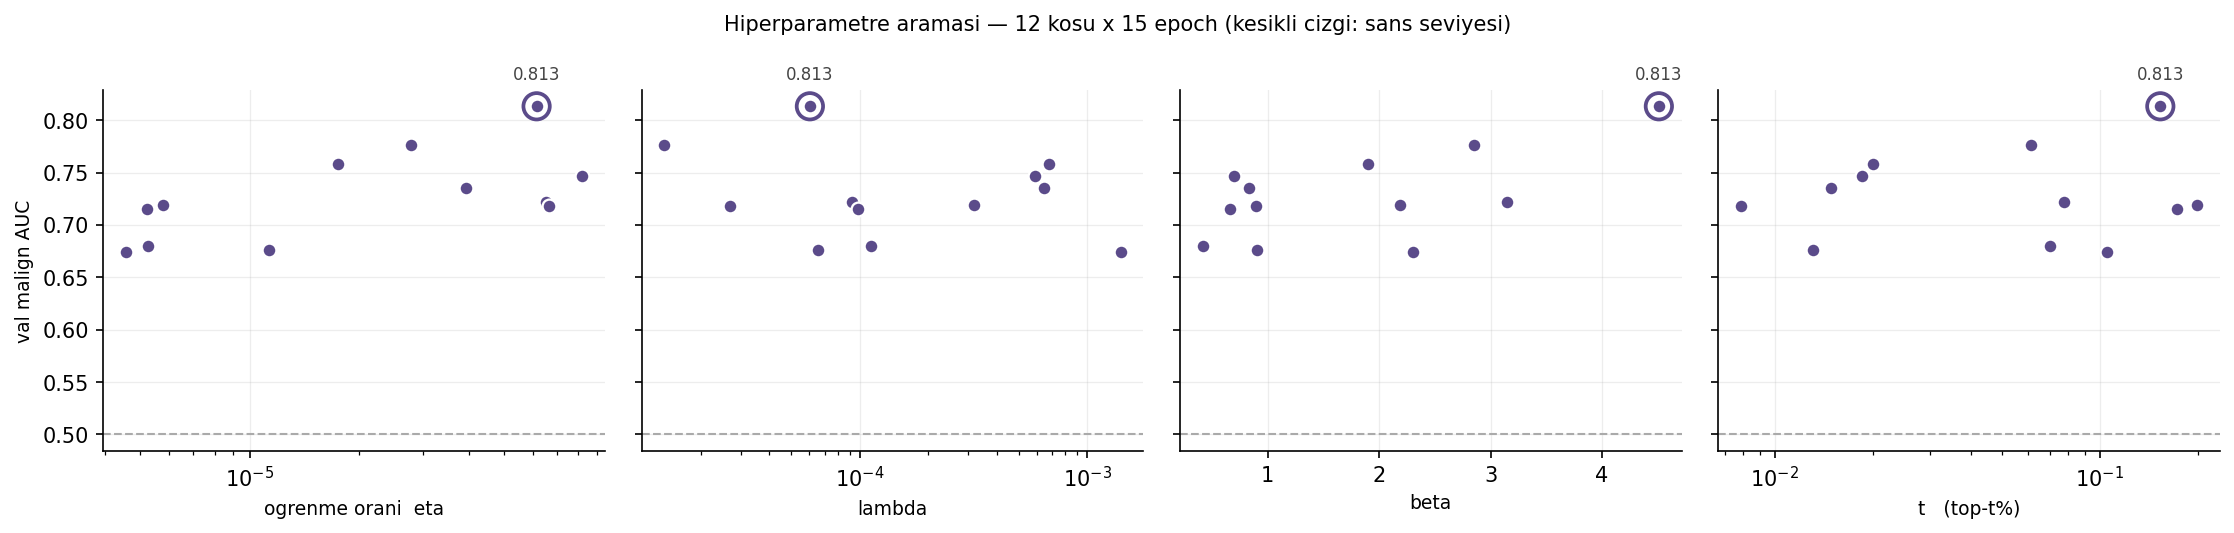
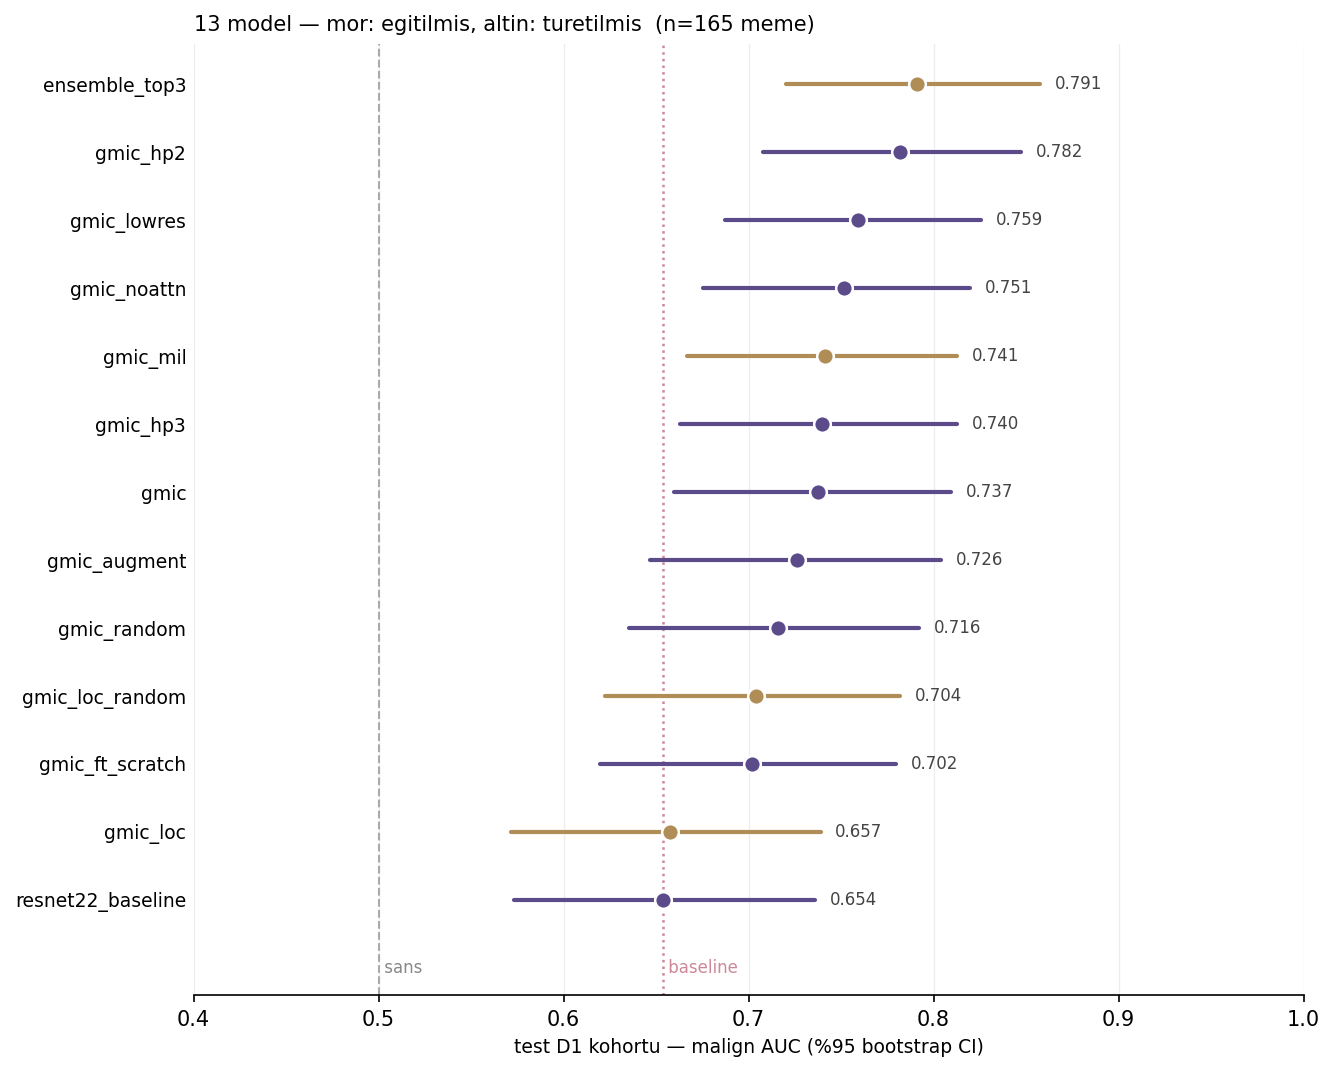
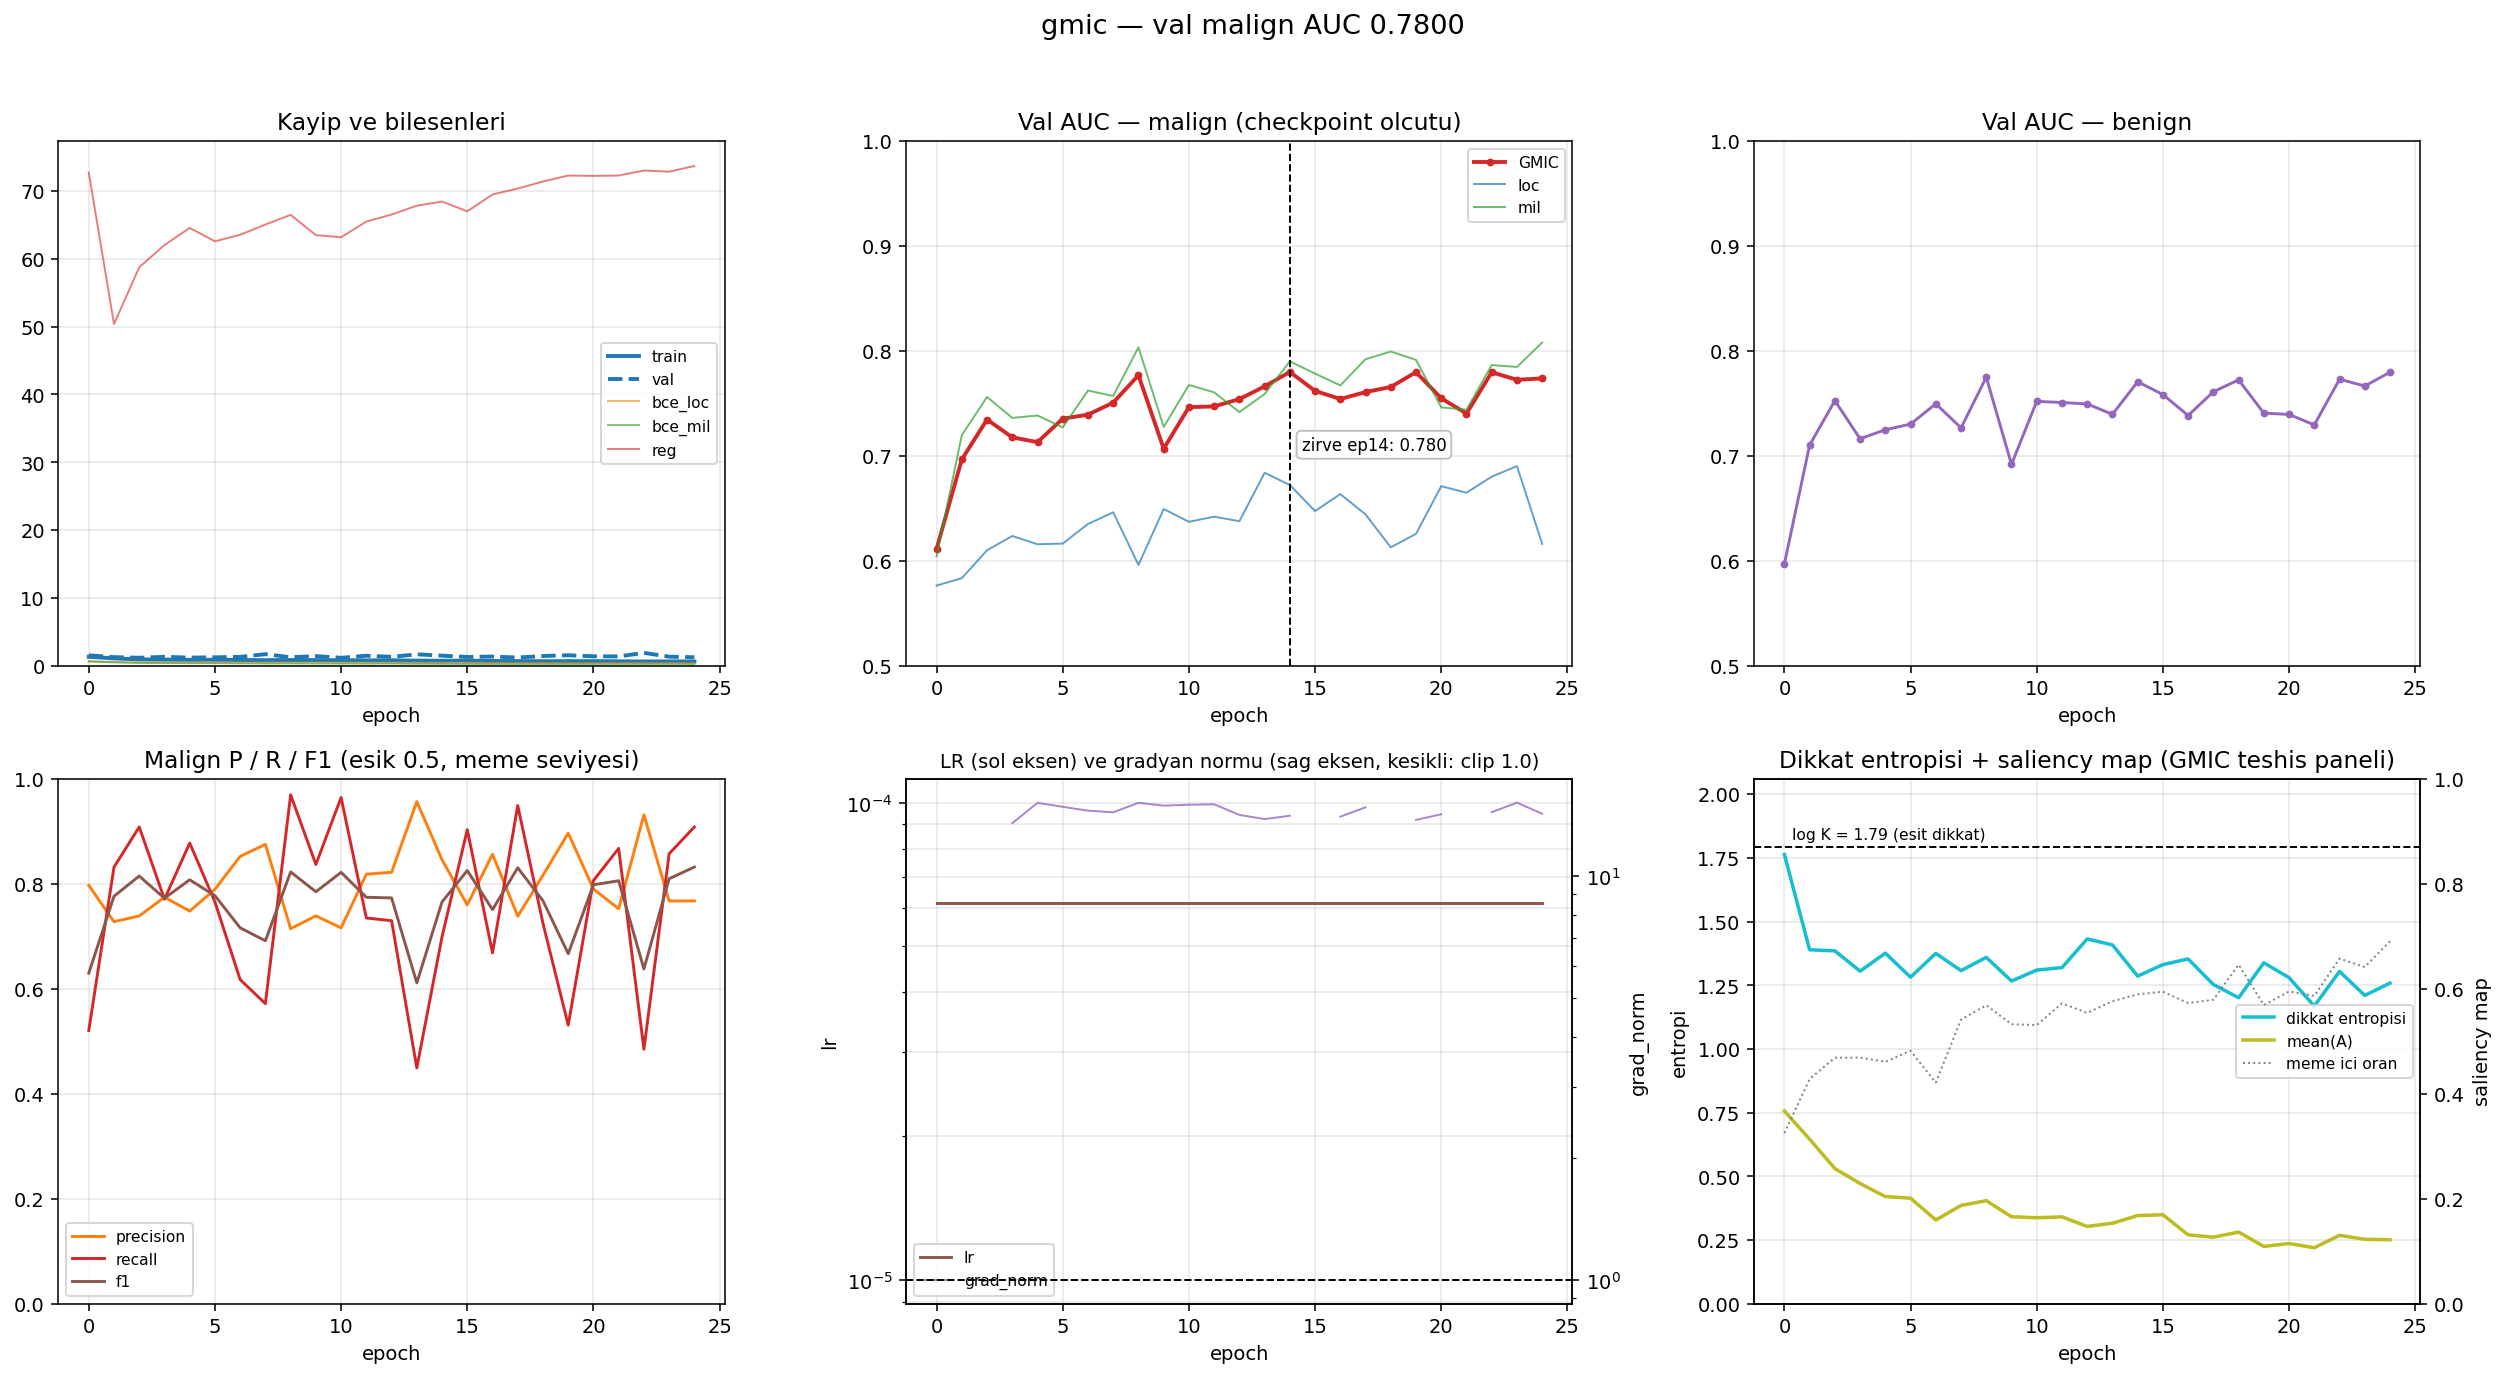
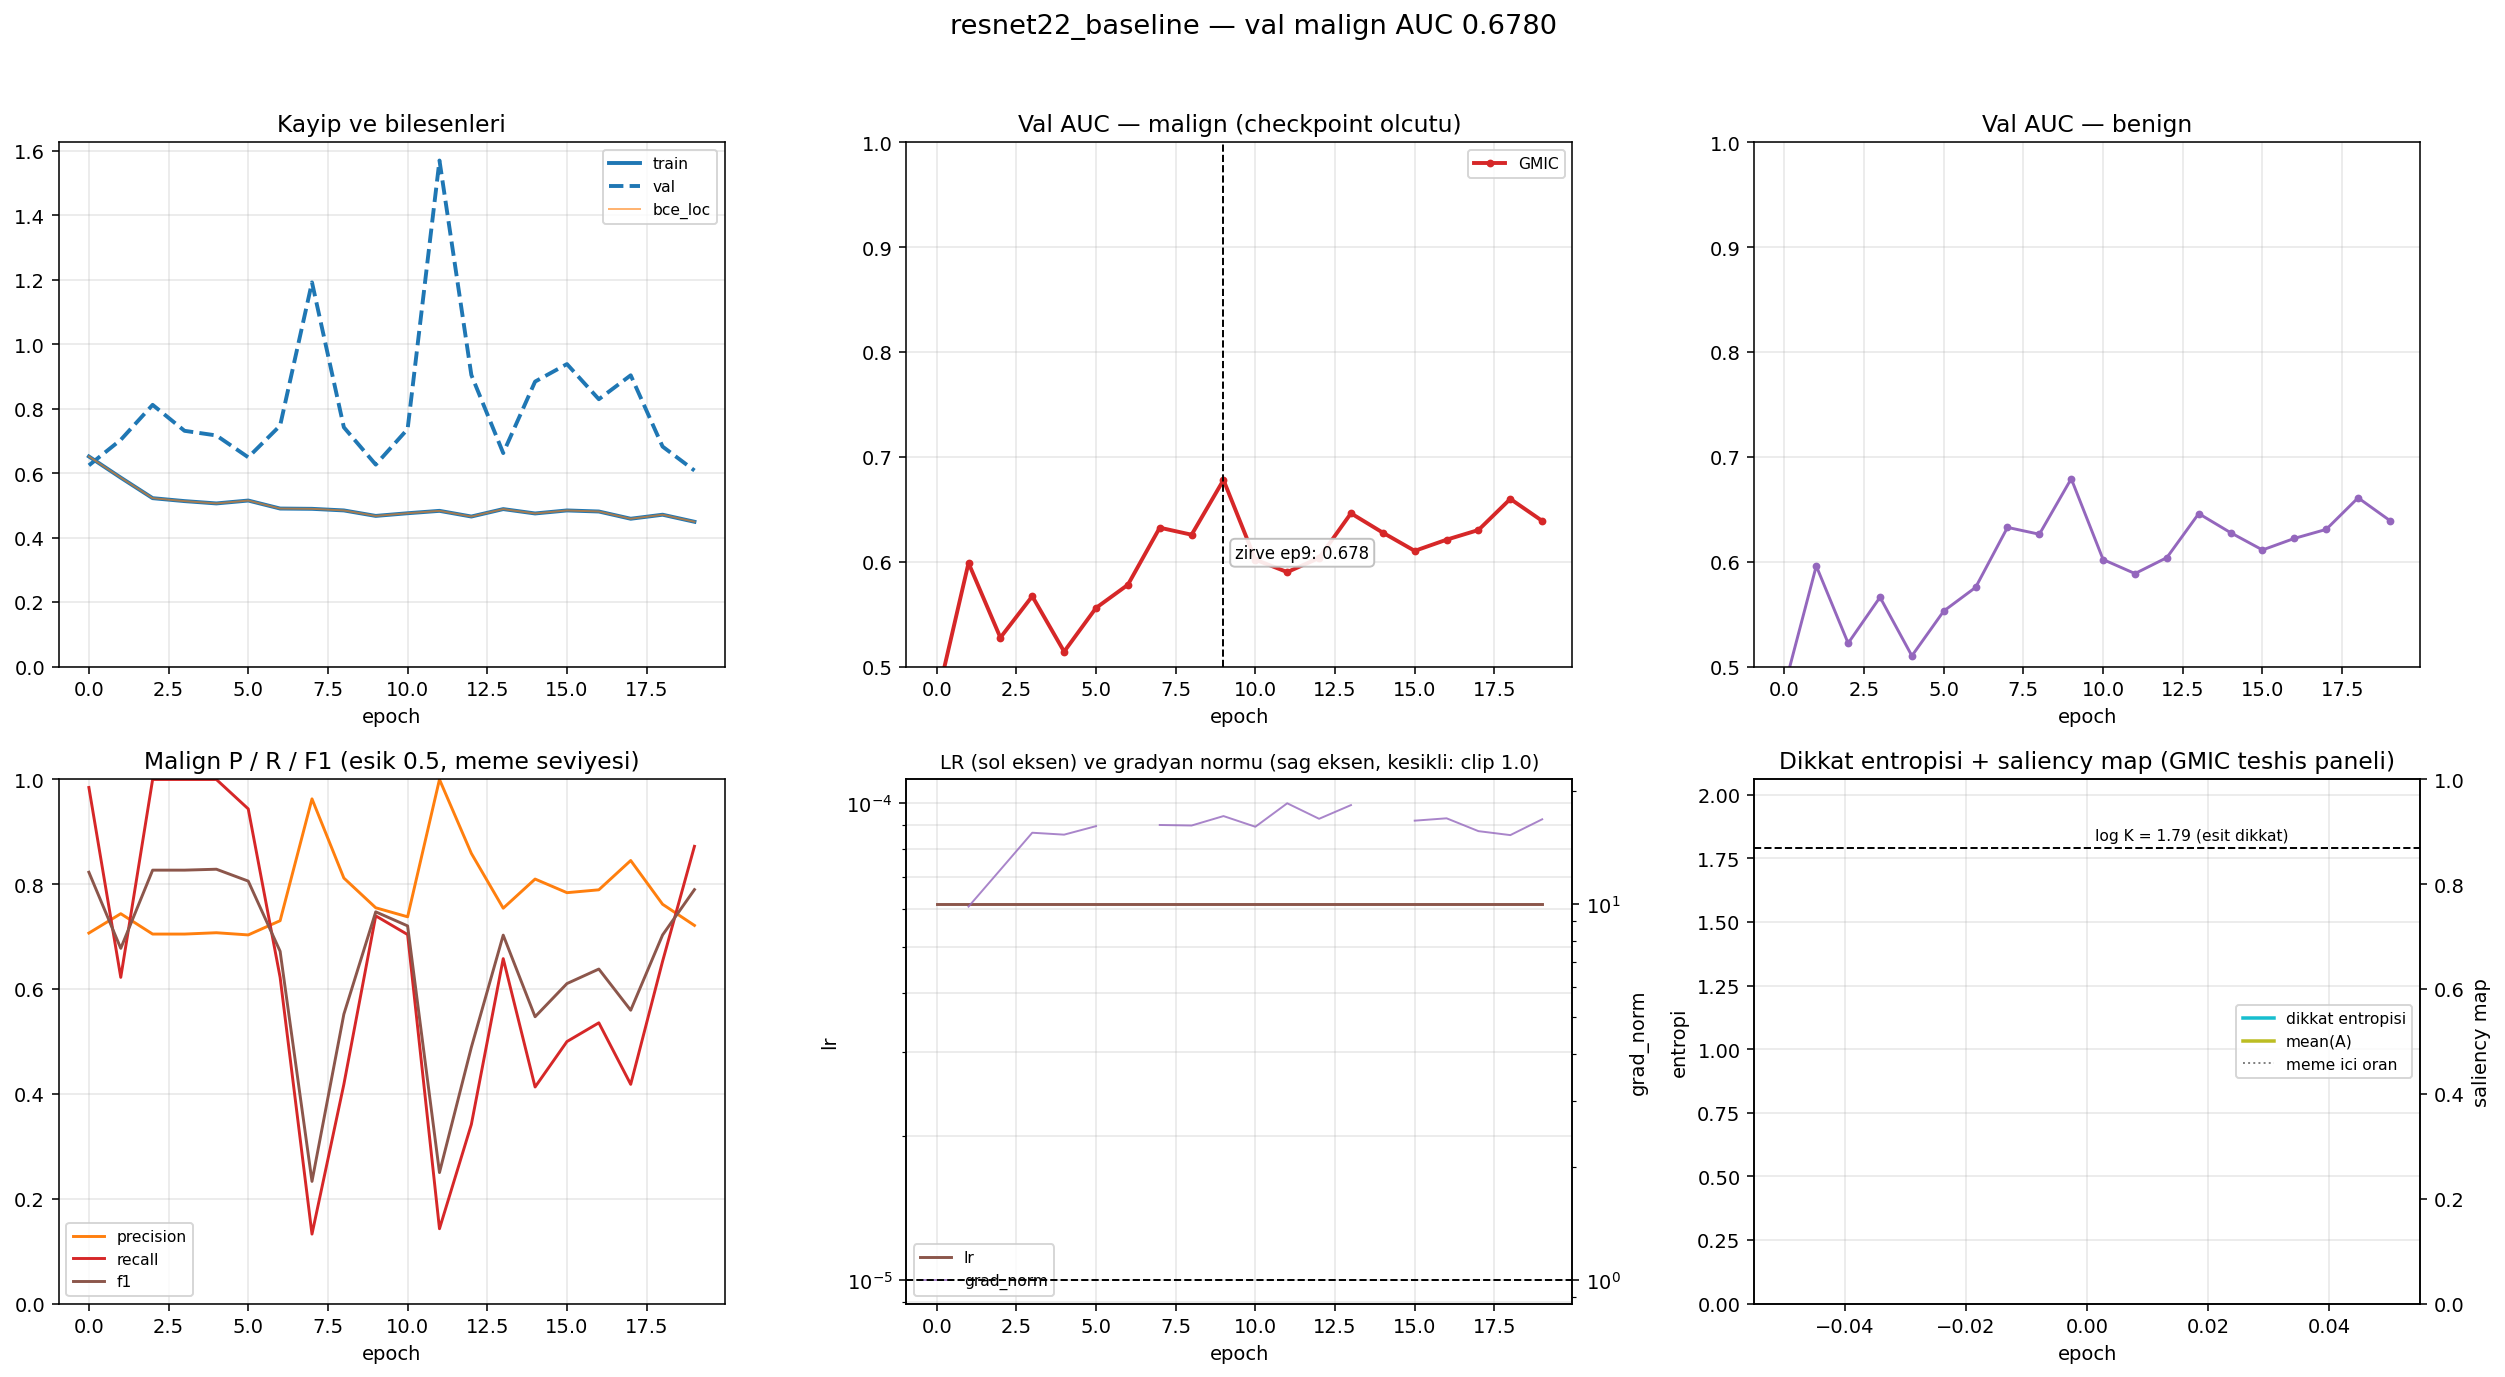
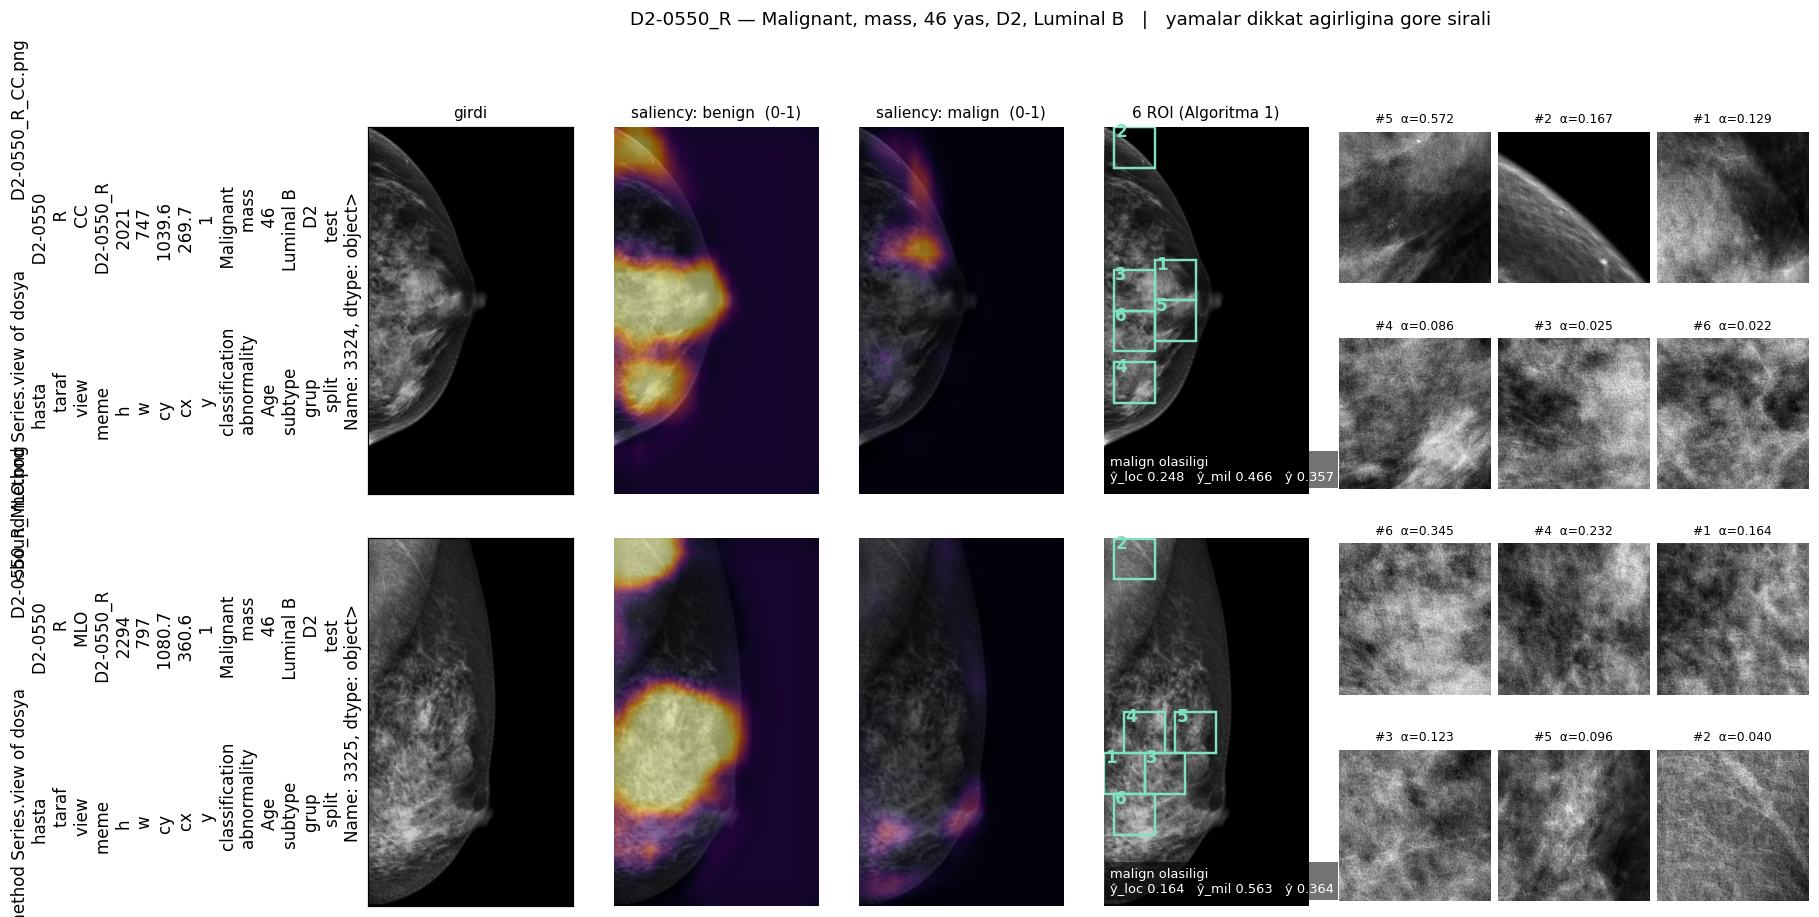
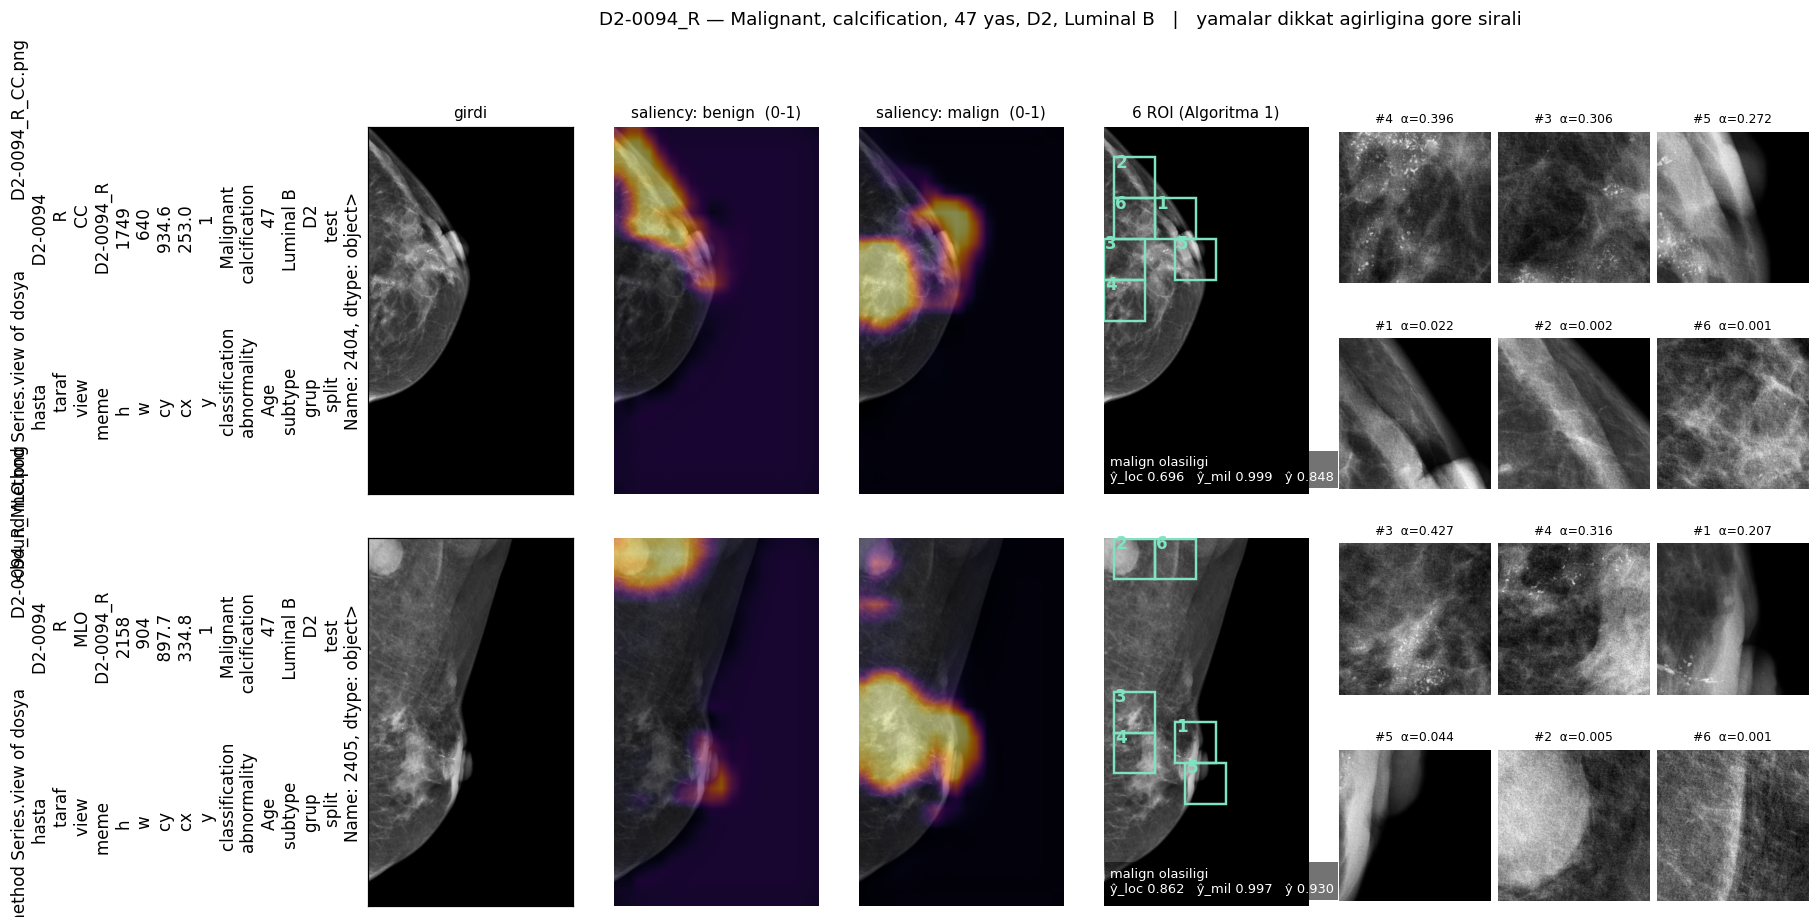
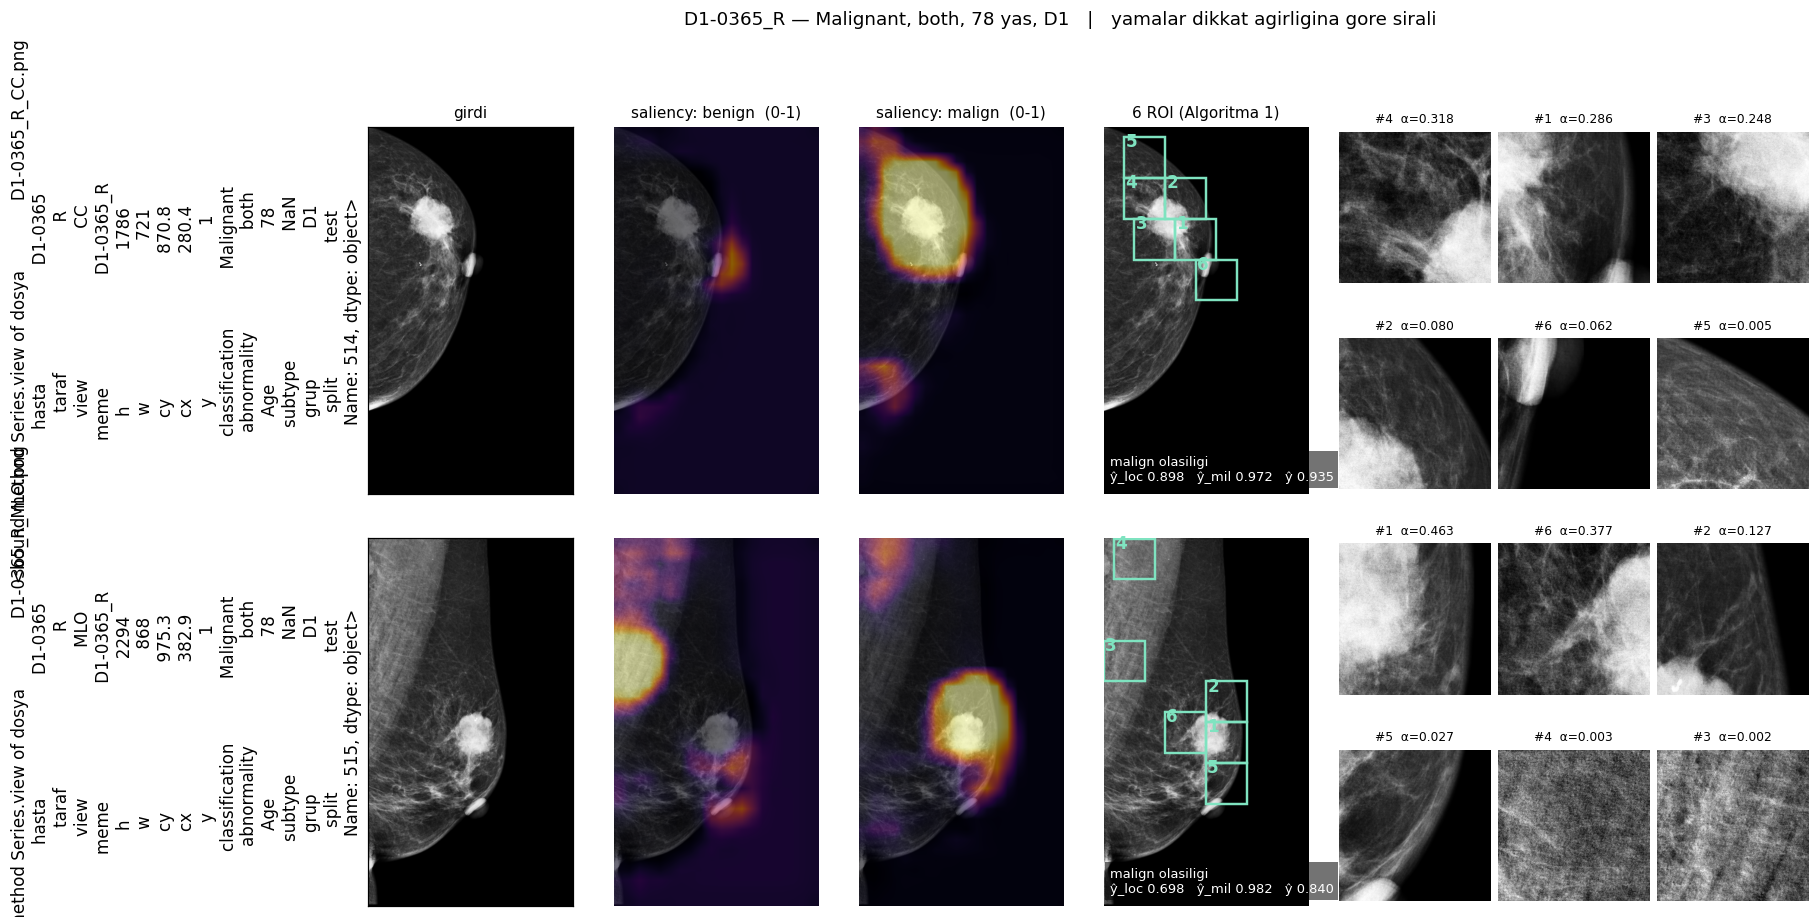
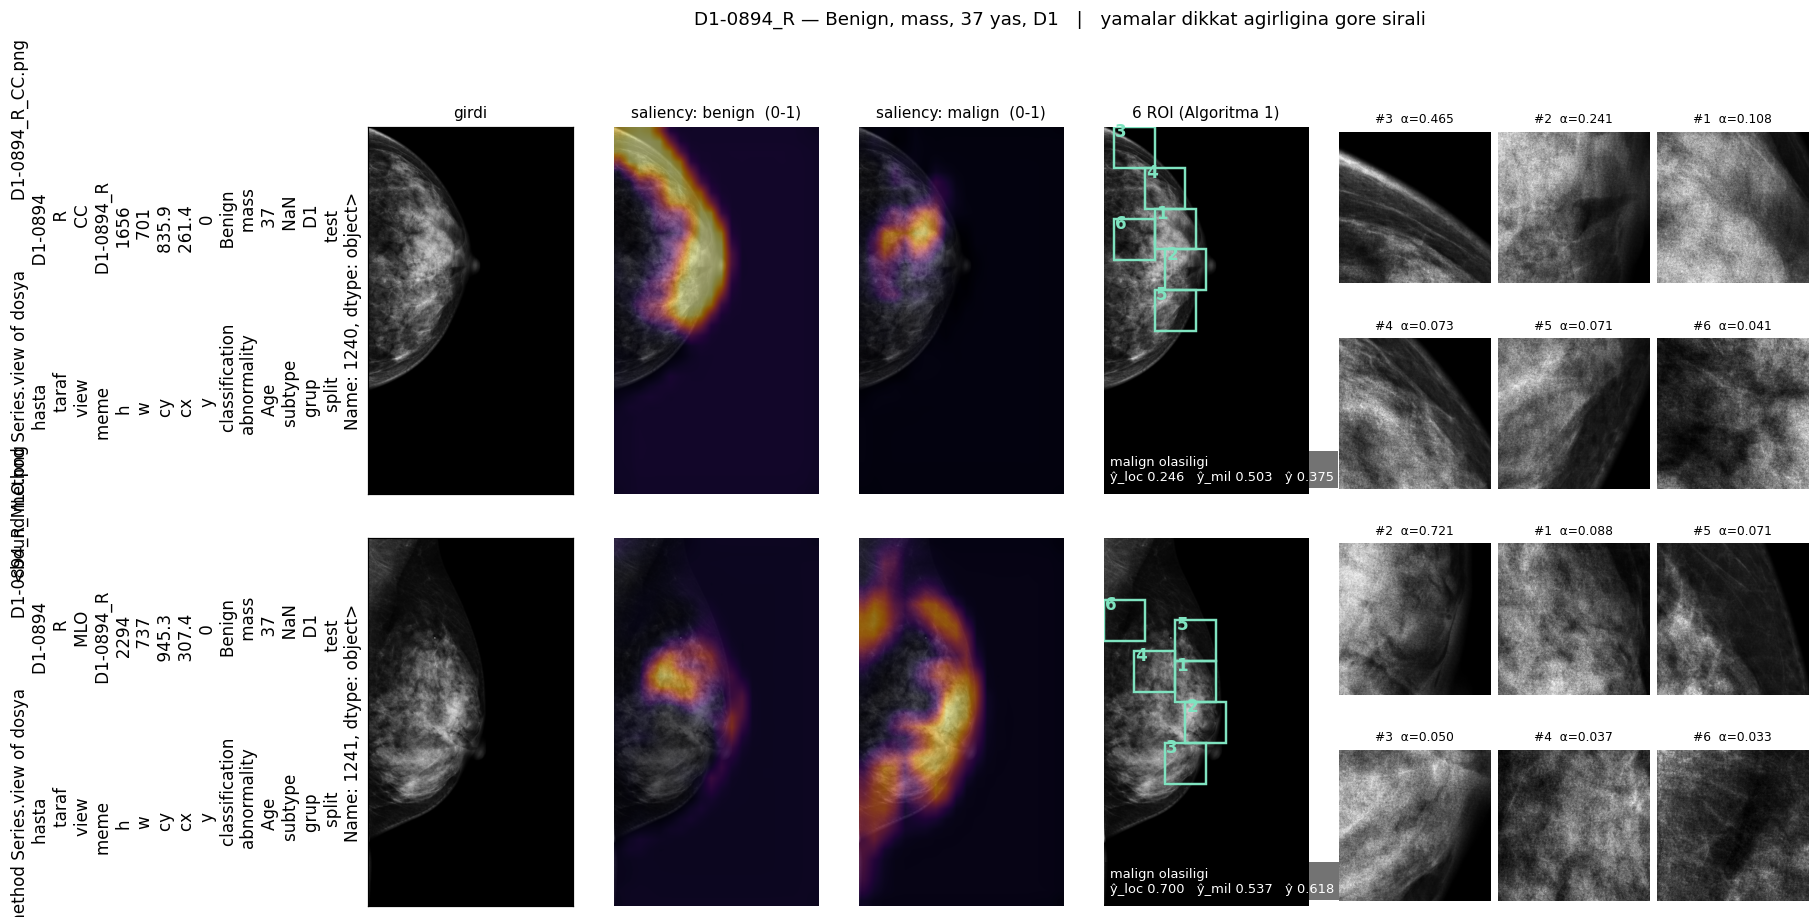
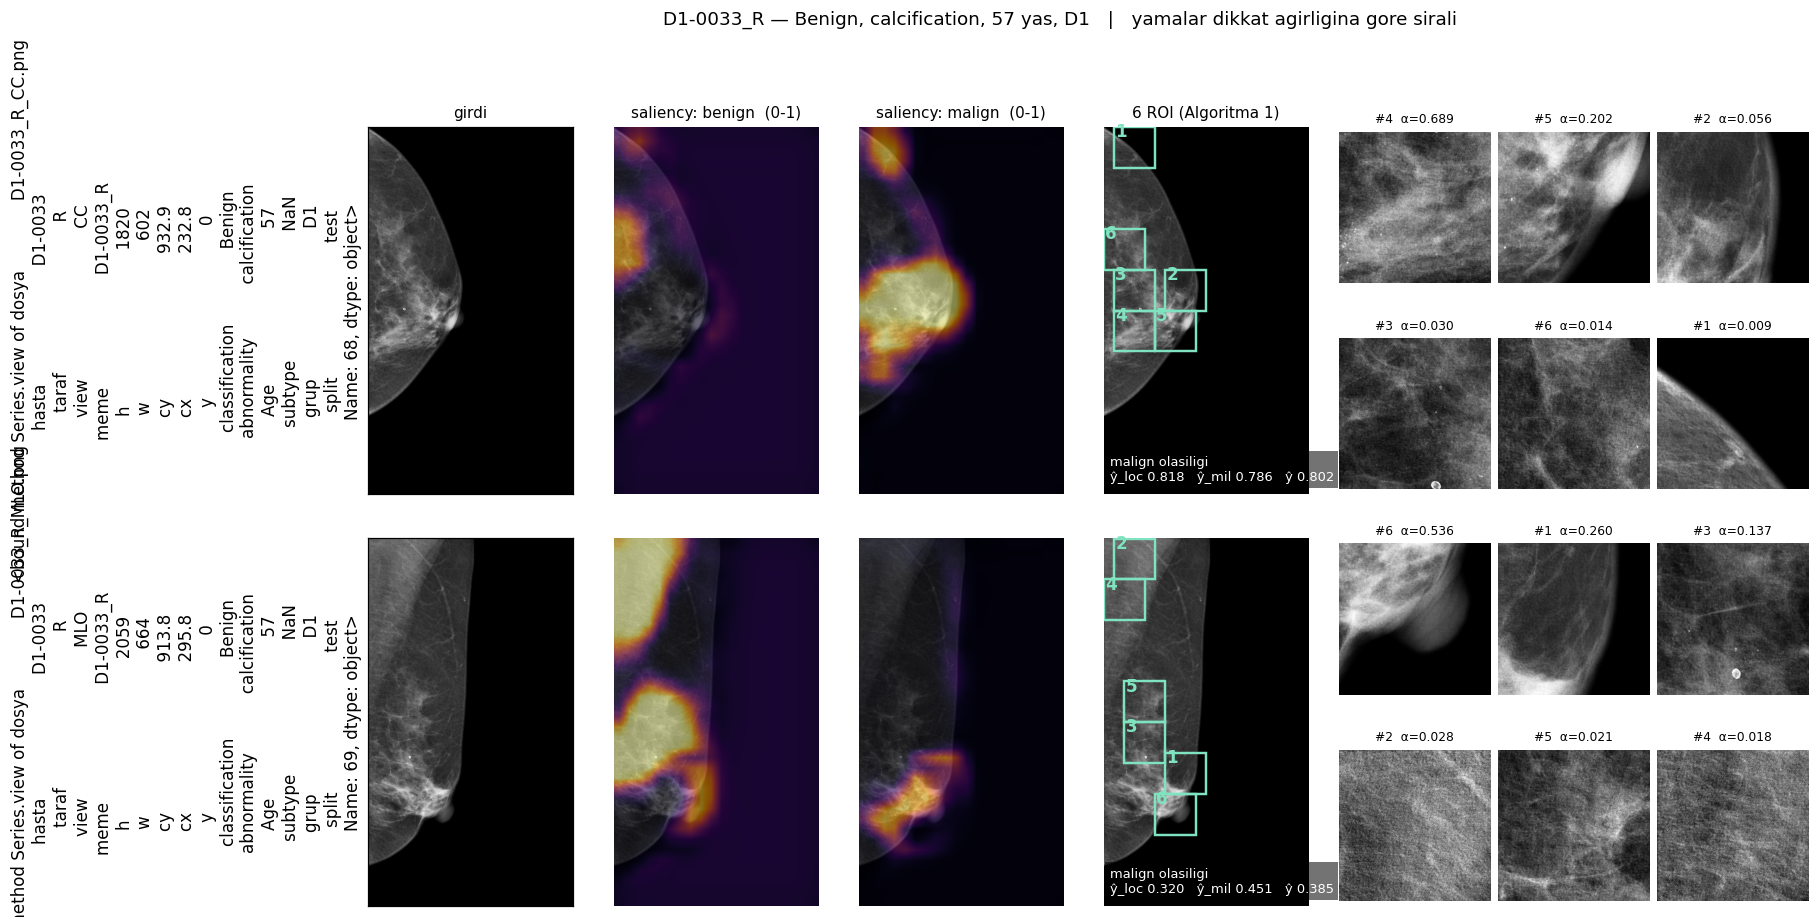
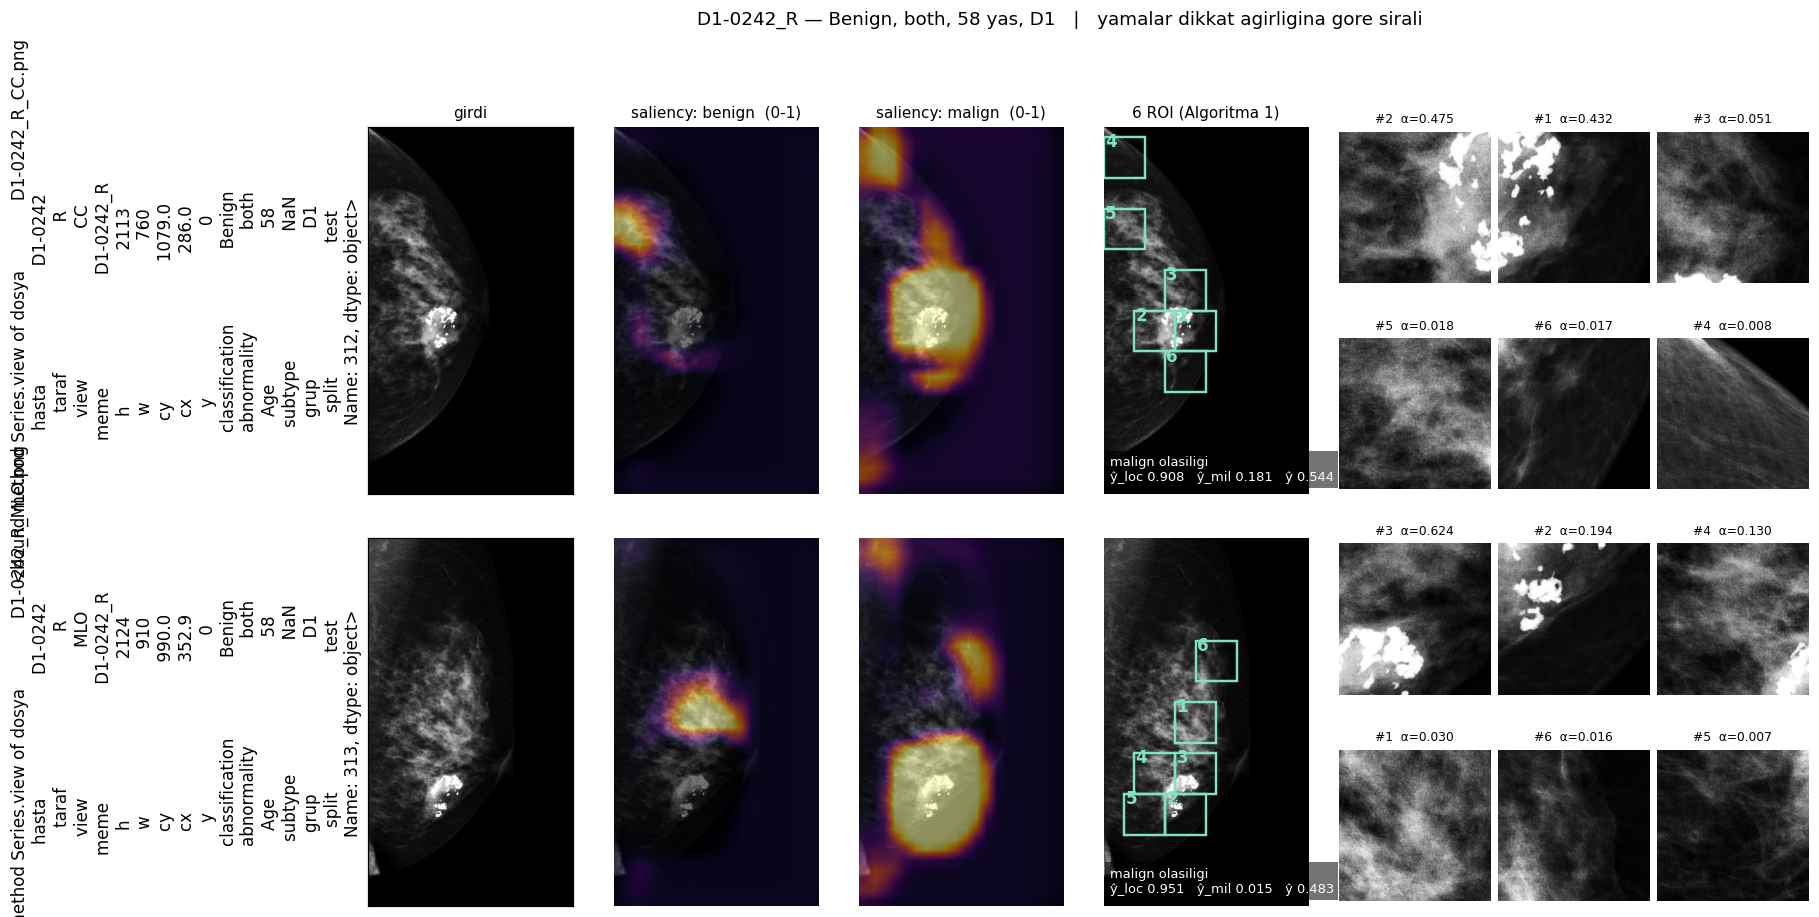

In [5]:
HTML = f"""<!-- gmic_cmmd_rapor.ipynb tarafindan uretildi -- elle duzenlenirse tekrar uretimde silinir -->
<meta charset="utf-8">
<style>
@page {{ size: A4; margin: 20mm 18mm; }}
* {{ box-sizing: border-box; }}
body {{ font-family: "Segoe UI", Calibri, Arial, sans-serif; font-size: 10.5pt; line-height: 1.55;
        color: #1a1a1a; max-width: 190mm; margin: 0 auto; }}
h1 {{ font-size: 17pt; line-height: 1.3; margin: 0 0 5pt; font-weight: 600; }}
h1 + .sub {{ font-size: 11pt; color: #555; margin: 0 0 20pt; }}
h2 {{ font-size: 13pt; margin: 20pt 0 8pt; padding-bottom: 3pt;
      border-bottom: 1.5px solid #2c5aa0; color: #2c5aa0; page-break-after: avoid;
      font-weight: 600; }}
h3 {{ font-size: 11pt; margin: 14pt 0 6pt; color: #1a3d6b; page-break-after: avoid;
      font-weight: 600; }}
p {{ margin: 0 0 8pt; text-align: justify; }}
table {{ border-collapse: collapse; width: 100%; margin: 9pt 0 6pt; font-size: 9.2pt;
         page-break-inside: avoid; }}
table.uzun {{ page-break-inside: auto; font-size: 8.6pt; }}
table.uzun tr {{ page-break-inside: avoid; }}
table.uzun td:first-child {{ white-space: nowrap; }}
th {{ background: #eef2f8; text-align: left; font-weight: 600; }}
th, td {{ border: 1px solid #c3ccd9; padding: 3.5pt 6pt; }}
td:not(:first-child), th:not(:first-child) {{ text-align: right;
                                              font-variant-numeric: tabular-nums; }}
figure {{ margin: 10pt 0 14pt; page-break-inside: avoid; text-align: center; }}
figure img {{ max-width: 100%; border: 1px solid #d5dae2; }}
.fig-vaka img {{ max-height: 118mm; width: auto; }}
figcaption {{ font-size: 8.5pt; color: #4a4a4a; margin-top: 5pt; text-align: left;
              line-height: 1.4; }}
.kutu {{ border-left: 3px solid #2c5aa0; background: #f6f9fd; padding: 8pt 12pt; margin: 10pt 0;
         page-break-inside: avoid; }}
.kutu p:last-child {{ margin-bottom: 0; }}
.uyari {{ border-left: 3px solid #b8860b; background: #fdfaf1; padding: 8pt 12pt; margin: 10pt 0;
          page-break-inside: avoid; }}
.uyari p:last-child {{ margin-bottom: 0; }}
.ozet {{ border: 1.5px solid #2c5aa0; background: #f6f9fd; padding: 10pt 14pt; margin: 12pt 0 16pt;
         page-break-inside: avoid; }}
.ozet p:last-child {{ margin-bottom: 0; }}
.tblnote {{ font-size: 8.5pt; color: #555; margin: 0 0 12pt; line-height: 1.4; }}
.eksik {{ color: #b3355a; font-size: 9pt; }}
.yeni-sayfa, .vaka-bolum {{ page-break-before: always; }}
.refs {{ font-size: 9.2pt; }} .refs li {{ margin-bottom: 5pt; }}
ul, ol {{ margin: 0 0 9pt; padding-left: 18pt; }} li {{ margin-bottom: 4pt; }}
</style>
<h1>Globally-Aware Multiple Instance Classifier Yönteminin CMMD2022 Veri Setinde
Yeniden Üretilmesi</h1>
<p class="sub">Shen ve ark. (MLMI 2019) &middot; {date.today().strftime('%d.%m.%Y')}</p>

<div class="ozet">
<p>Çalışmanın ana bulgusu, makalenin merkezi iddiasının bu veri setinde de geçerli olmasıdır:
GMIC, aynı backbone'u kullanan ResNet-22 baseline'ını {vir(fark)} AUC farkıyla aşmaktadır
(p = {vir(pdeg)}). Makalede bildirilen fark 0,073 olup, veri setinin yaklaşık 120 kat küçük
olmasına rağmen aynı büyüklükte bir kazanç elde edilmiştir. Hiperparametre aramasından çıkan
ilk üç konfigürasyonun ensemble'ı {vir(ens.auc)} ile en yüksek sonucu vermekte ve tek başına
tam modeli de anlamlı olarak aşmaktadır (p = {vir(ens.p_gmic)}). Buna karşılık ablasyon
varyantlarının hiçbiri tam modelden istatistiksel olarak ayırt edilememektedir; Bölüm 5.4'te
gösterildiği üzere bu, ablasyonların etkisiz olduğu anlamına gelmez, mevcut örneklem
büyüklüğünün bu büyüklükteki farkları ölçmeye yetmediği anlamına gelir.</p>
</div>

<h2>1. Amaç ve Kapsam</h2>
<p>Shen ve ark., yüksek çözünürlüklü mamografi görüntülerinde tüm görüntüyü işleyen bir global
ağı, saliency map'ten seçilen patch'ler üzerinde çalışan bir MIL modülü ile birleştiren GMIC
mimarisini önermiştir. Bu çalışmanın amacı, söz konusu yöntemi CMMD2022 veri setinde mümkün
olduğunca birebir uygulamak ve makalede bildirilen ablasyon sıralamasının bu ölçekte korunup
korunmadığını ölçmektir.</p>
<p>Hedef, makaledeki mutlak AUC seviyesine ulaşmak değildir. Makale 229.426 tetkik üzerinde
çalışırken burada 1.771 hasta bulunmaktadır; iki çalışmanın mutlak değerleri doğrudan
karşılaştırılabilir nitelikte değildir. Değerlendirme, yöntemin bileşenleri arasındaki göreli
sıralama üzerinden yapılmıştır.</p>

<h2>2. Veri</h2>
<p>CMMD2022 veri seti (TCIA arşivi, Kaggle dağıtımı tommyngx/cmmd2022) 5.202 DICOM görüntü ve
1.775 hasta içermektedir. Eğitime hazır hale getirilirken üç eleme uygulanmıştır.</p>
<p>Birincisi, iki memesi de görüntülenmiş ancak yalnızca biri için biyopsi sonucu bulunan
hastalarda etiketsiz kontralateral memeler (729 meme) veri dışında bırakılmıştır. Patolojik
doğrulama olmadan bu memelerin negatif kabul edilmesi, etiket gürültüsü yaratacaktır.</p>
<p>İkincisi, arşivin uyardığı yinelenen görüntüler md5 karşılaştırmasıyla doğrulanmıştır.
D1-0808 ve D1-1292 kayıtları aynı sağ CC görüntüsünü birbirine zıt sınıflarla paylaşmaktadır;
benzer çakışmaların tespit edildiği toplam dört hasta veri dışı bırakılmıştır.</p>
<p>Üçüncüsü, bölme hasta seviyesinde yapılmış, aynı hastanın tüm görüntüleri tek bir kümede
tutulmuştur. Kalan veri 1.867 meme ve 3.734 görüntüdür; eğitim, doğrulama ve test kümelerine
%70/15/15 oranında ayrılmıştır.</p>
<p>Görüntüler 8 bit derinlikte ve ön-pencerelenmiş olarak saklanmaktadır (WindowCenter 128,
Width 256, VOI LUT SIGMOID). Bu ayrıntı sonuçların yorumlanmasında önem taşımaktadır: makalenin
korumayı hedeflediği geniş dinamik aralık bu veri setinde baştan mevcut değildir.</p>

{gorsel(KOK / 'ozet' / 'veri_kesfi.png', 'Şekil 1. Sınıf, alt küme (D1/D2) ve yaş dağılımları.')}

<div class="uyari">
<p>Veri setinde belirgin bir confounder yapısı bulunmaktadır. Yalnızca yaş kullanıldığında
0,682; yalnızca D1/D2 alt küme göstergesi kullanıldığında 0,776; ikisi birlikte kullanıldığında
0,847 AUC elde edilmektedir. Bu nedenle birincil değerlendirme kohortu olarak D1 seçilmiştir
(n = {n_meme}, {n_malign} malign). D2 test kohortunda {n_d2} memenin {n_d2_malign} tanesi
malign olduğundan, bu alt kümede AUC pratik olarak tanımsızdır.</p>
</div>

<h2>3. Yöntem</h2>

<h3>3.1 Mimari</h3>
<p>Mimari makaledeki tanıma bağlıdır. Lokalizasyon modülü f_d olarak ResNet-22 kullanılmakta,
çıktısı 1&times;1 konvolüsyon ve sigmoid ile sınıf başına bir saliency map'e
dönüştürülmektedir. Tespit modülü, makaledeki Algoritma 1 uyarınca bu harita üzerinden
örtüşmeyen K = {K} adet ROI seçmektedir. MIL modülü, seçilen patch'leri ImageNet pretrained
ResNet-18 (f_t) ile kodlamakta ve Ilse ve ark. (2018) tarafından önerilen gated attention
mekanizmasıyla birleştirmektedir.</p>
<p>Loss fonksiyonu, her iki dalın çıktısı için ayrı BCE terimleri ve saliency map üzerinde bir
regularization teriminden oluşmaktadır:
L = &Sigma;<sub>c</sub> [ BCE(y<sub>c</sub>, &#375;<sub>loc,c</sub>) +
BCE(y<sub>c</sub>, &#375;<sub>mil,c</sub>) ] + &lambda; L<sub>reg</sub>.
Çıkarımda iki dalın ortalaması alınmaktadır.</p>
<p>Tespit modülü türevlenebilir olmadığından MIL loss'unun gradyanı f_d'ye ulaşmamakta, iki dal
yalnızca ortak pooling fonksiyonu üzerinden bağlanmaktadır. Bu davranış uygulamada ayrı bir
testle doğrulanmıştır.</p>

<h3>3.2 ROI seçimi (Algoritma 1)</h3>
<p>Tespit modülü, saliency map üzerinden birbiriyle önemli ölçüde örtüşmeyen K adet bölge
seçmektedir. Makaledeki algoritma açgözlü çalışmaktadır: harita önce sınıf başına min-max
normalize edilir ve sınıflar toplanır; ardından K kez, patch boyutuna karşılık gelen pencere
içinde toplamı en yüksek konum seçilir ve seçilen bölge haritadan silinerek bir sonraki seçimin
aynı yere düşmesi engellenir. Seçilen konumlar saliency map ölçeğinden girdi ölçeğine taşınır ve
patch'ler orijinal çözünürlükten kesilir; böylece MIL modülü aşağı örneklenmemiş piksellerle
çalışır.</p>
<p>Uygulamada tek sapma silme değerindedir. Makale ve yayınlanan kod seçilen bölgeyi sıfırlar.
Min-max normalizasyon sonrası arka plan zaten tam sıfır olduğundan, tepeler sıfırlandığında
harita her yerde sıfıra eşitlenmekte ve argmax sürekli aynı konumu (0,0) döndürmektedir; bu
durumda aynı patch K kez MIL modülüne girmektedir. Silme değeri −1 olarak değiştirilmiştir.
Harita pozitif değerler içerdiği sürece davranış sıfır ile aynı, dejenere durumda ise doğrudur.
Bu davranış, düz bir saliency map ile ayrıca test edilmiştir.</p>

<h3>3.3 Ön işleme</h3>
<p>Makale ön işleme adımlarını Wu ve ark. (2019) çalışmasına atıfla geçmekte ve augmentation
listesi vermemektedir. Bu nedenle adımlar yazarların yayınladığı uygulamadan alınmıştır: meme
dokusunun çevresindeki arka plan crop edilmekte, sağ memeler yatay çevrilerek tüm görüntüler
aynı yöne bakacak şekilde normalize edilmekte ve görüntü başına z-score uygulanmaktadır. Girdi
çözünürlüğü {GLOBAL_SIZE[0]}&times;{GLOBAL_SIZE[1]}, patch boyutu
{PATCH_SIZE}&times;{PATCH_SIZE} olarak korunmuştur.</p>

{gorsel(KOK / 'ozet' / 'onisleme_dogrulama.png', 'Şekil 2. Crop, yön normalizasyonu ve z-score sonrası örnek görüntüler.')}

<h3>3.4 Augmentation</h3>
<p>Makale augmentation listesi vermemekte, yayınlanan uygulamada ise tek bir augmentation
bulunmaktadır: crop penceresinin merkezine ve boyutuna eklenen rastgele gürültü. Bu tercih
mamografiye özgüdür. Yatay çevirme kullanılamaz, çünkü ön işleme adımında tüm görüntüler aynı
yöne bakacak şekilde normalize edilmiştir; çevirme bu bilgiyi yok eder. Döndürme ve ölçek
dönüşümleri de rutin olarak uygulanmaz, zira meme pozisyonu çekim protokolü tarafından
standartlaştırılmıştır.</p>
<p>Bu çalışmada aynı tercih korunmuştur: eğitimde pencere merkezi en fazla 100 piksel kaydırılır
ve pencere boyutu en fazla 100 piksel değiştirilerek hedef boyuta yeniden ölçeklenir; doğrulama
ve test kümelerinde gürültü uygulanmaz. Boyut gürültüsünün tam semantiği yayınlanan koddan
çıkarılamadığı için yaklaşık %4 büyüklüğünde bir zoom değişimi olarak uygulanmıştır.</p>

{gorsel(KOK / 'ozet' / 'pencere_augmentasyon.png', 'Şekil 3. Aynı görüntünün gürültüsüz hali (doğrulama/test) ve eğitimde üretilen üç farklı crop penceresi.')}

<p>Veri ölçeğinin makaledekinden yaklaşık 120 kat küçük olması, bu minimal augmentation
tercihinin bu ölçekte de doğru olup olmadığı sorusunu doğurmaktadır. Soru açık bırakılmamış, ek
bir ablasyon olarak ölçülmüştür (Bölüm 5.1, gmic_augment): mamografiye uygun daha geniş bir
augmentation seti eklendiğinde sonuç değişmemiştir.</p>

<h3>3.5 Hiperparametre araması</h3>
<p>Makale dört parametre üzerinde logaritmik ölçekte rastgele arama yapmakta ve 100 model
eğitmektedir. Mevcut hesaplama bütçesi bunu karşılamadığından, aynı aralıklarda 12 koşu ve koşu
başına 15 epoch ile daraltılmış bir arama yürütülmüştür. Seçim ölçütü makaledekiyle aynı
tutulmuş, doğrulama kümesi malign AUC değeri kullanılmıştır. Seçilen konfigürasyon tüm
ablasyonlarda sabitlenmiştir: &eta; = {vir_e(SECIM['HP']['lr'])},
&lambda; = {vir_e(SECIM['HP']['lam'])}, &beta; = {vir(SECIM['HP']['beta'])},
t = {vir(SECIM['HP']['t'], 4)}.</p>

{gorsel(KOK / 'arama' / 'arama_dagilim.png', 'Şekil 4. Her hiperparametreye karşı doğrulama kümesi malign AUC değeri. Halka ile işaretlenen nokta seçilen konfigürasyondur.')}

<div class="uyari">
<p>Aramada bir kenar etkisi gözlenmiştir. Kazanan &beta; değeri {vir(SECIM['HP']['beta'], 2)}
olup makaledeki aralığın üst sınırına (4,95) oldukça yakındır; seçilen öğrenme oranı da
örneklenen en büyük değerlere yakındır. On iki çekiliş ile dört boyutlu arama uzayının üst
bölgesi yeterince taranamamıştır. Aralıklar makaleden olduğu gibi alındığı için
genişletilmemiş, bu durum bir sınırlama olarak kaydedilmiştir.</p>
</div>

<h2 class="yeni-sayfa">4. Makale &rarr; CMMD2022 Uyarlamaları</h2>
<p>Aşağıdaki tablo yöntemin her adımını makaledeki tanımla karşılaştırmakta, farklılık
bulunan yerlerde yapılan uyarlamayı ve gerekçesini vermektedir. Tablonun ilk dokuz satırı
değiştirilmeden uygulanan bileşenleri, kalan satırlar veri setinin dayattığı uyarlamaları
göstermektedir. Uyarlamaların hiçbiri mimariyi değiştirmemekte, yalnızca veri setinin
makaledekinden ayrıldığı noktalara karşılık gelmektedir.</p>
{tablo(UYARLAMA).replace('class="veri"', 'class="veri uzun"')}

<h2>5. Sonuçlar</h2>
<p>Değerlendirme test kümesinin D1 kohortu üzerinde yapılmıştır: {n_meme} meme, bunların
{n_malign} tanesi malign, {n_meme - n_malign} tanesi benigndir. Güven aralıkları sınıfa göre
stratified bootstrap ile 2.000 tekrar üzerinden hesaplanmıştır. Model karşılaştırmalarında
DeLong testi kullanılmıştır; aynı memeler üzerinde üretilen tahminler korelasyonlu olduğundan
eşleşmiş bir test gereklidir.</p>

<h3>5.1 Ana karşılaştırma</h3>
{tablo(ana)}
<p class="tblnote">&Delta; sütunları AUC farkını, p sütunları DeLong testinin iki yönlü p
değerini göstermektedir. Türetilmiş olarak işaretlenen modeller ayrıca eğitilmemiş, mevcut
çıktılardan hesaplanmıştır: gmic_loc tam modelin global dalı, gmic_mil MIL dalı,
gmic_loc_random tam modelin global dalı ile rastgele patch varyantının MIL dalının ortalaması,
ensemble_top3 ise aramadan çıkan ilk üç konfigürasyonun ortalamasıdır.</p>

{gorsel(DEG_DIR / 'forest_auc.png', 'Şekil 5. Modellerin AUC değerleri ve %95 bootstrap güven aralıkları. Noktalı dikey çizgi baseline seviyesini göstermektedir.')}

<h3>5.2 Makale sonuçlarıyla karşılaştırma</h3>
<p>Aşağıdaki tablo, makalenin Tablo 1'inde bildirilen malign AUC değerleri ile bu çalışmada D1
kohortunda elde edilen değerleri yan yana vermektedir. Mutlak değerler karşılaştırılabilir
değildir; anlamlı olan varyantlar arası sıralamadır.</p>
{tablo(KARSI)}
<p class="tblnote">Makale sütunu Shen ve ark. (2019) Tablo 1'den alınmıştır. Bu çalışmada
GMIC-loc, GMIC-mil ve GMIC-loc-random varyantları ayrıca eğitilmemiş, tam modelin ve rastgele
patch varyantının çıktılarından türetilmiştir.</p>
<p>Baseline ile tam model arasındaki fark her iki çalışmada da aynı yöndedir ve benzer
büyüklüktedir (makalede 0,073, burada {vir(fark)}). GMIC-random varyantının tam modelin altında
kalması da ortaktır. Buna karşılık GMIC-loc varyantı makalede baseline'ı açıklıkla aşarken bu
çalışmada baseline seviyesinde kalmakta, GMIC-noattn ise makalede baseline seviyesine düşerken
burada tam modelden ayırt edilememektedir.</p>

<h3>5.3 Doğrulanan bulgular</h3>
<p>GMIC, baseline modelini {vir(gmic_auc)} karşısında {vir(base_auc)} ile aşmaktadır; fark
{vir(fark)} olup p = {vir(pdeg)} düzeyinde anlamlıdır. Bu karşılaştırma çalışma tasarımında
önceden belirlendiğinden çoklu karşılaştırma düzeltmesine tabi değildir.</p>
<p>İlk üç konfigürasyonun ensemble'ı {vir(ens.auc)}
[{vir(ens.ci_alt)}&ndash;{vir(ens.ci_ust)}] ile en yüksek sonucu vermekte ve tek başına tam
modeli de anlamlı olarak aşmaktadır (p = {vir(ens.p_gmic)}). Bu bulgu, arama sonuçlarında ilk üç
konfigürasyonun birbirinden ayırt edilememesiyle tutarlıdır.</p>
<p>Global dalın tek başına yetersiz kaldığı görülmektedir. gmic_loc varyantı
{vir(g.loc['gmic_loc', 'auc'])} değerinde olup baseline'dan farksızdır
(p = {vir(g.loc['gmic_loc', 'p_resnet22_baseline'], 2)}) ve tam modelden anlamlı olarak düşüktür
(p = {vir(g.loc['gmic_loc', 'p_gmic'])}). Makalede GMIC-loc varyantı 0,885 ile baseline'ı (0,827)
açıklıkla aşmaktaydı. Bu veri setinde performansı taşıyan bileşen MIL dalıdır; tam model ile
gmic_mil arasında anlamlı fark bulunmamaktadır
(p = {vir(g.loc['gmic_mil', 'p_gmic'], 2)}). Makaleden ayrışan en belirgin bulgu budur.</p>

<h3>5.4 Ölçülemeyen farklar</h3>
<p>Ablasyon varyantlarının hiçbiri tam modelden istatistiksel olarak ayırt edilememektedir.
Attention mekanizmasının devre dışı bırakıldığı varyant için
p = {vir(g.loc['gmic_noattn', 'p_gmic'], 2)}, yarı çözünürlük varyantı için
p = {vir(g.loc['gmic_lowres', 'p_gmic'], 2)}, rastgele patch varyantı için
p = {vir(g.loc['gmic_random', 'p_gmic'], 2)}, ImageNet pretrained ağırlıkları olmadan eğitilen
varyant için p = {vir(g.loc['gmic_ft_scratch', 'p_gmic'], 2)} elde edilmiştir.</p>
<p>Bu sonucun doğru yorumu, söz konusu bileşenlerin katkısız olduğu değil, katkılarının mevcut
örneklem büyüklüğünde ölçülemediğidir. Ortalama güven aralığı genişliği
{vir(KT.ci_genislik.mean())} iken makalede bildirilen ablasyon etkileri 0,02 ile 0,08
aralığındadır; aranan etki büyüklüğü, ölçüm belirsizliğinin altında kalmaktadır.</p>

<div class="uyari">
<p>Baseline'a karşı toplam {len(KT) - 1} karşılaştırma yapılmıştır. &alpha; = 0,05 düzeyinde
tesadüfen bir yanlış pozitif gözlenmesi beklenir. Bonferroni düzeltmesi uygulandığında
(eşik 0,05/{len(KT) - 1} = {vir(0.05 / (len(KT) - 1), 4)}) yalnızca
{', '.join(KT[KT.p_resnet22_baseline < 0.05 / (len(KT) - 1)].model)} varyantları anlamlı
kalmaktadır. Keşifsel nitelikteki ablasyon karşılaştırmaları bu eşikle değerlendirilmelidir;
önceden belirlenmiş birincil hipotez bu düzeltmenin kapsamı dışındadır.</p>
</div>

<h3>5.5 Alt gruplar</h3>
{tablo(AG.assign(kirilim=AG.kirilim.replace({'yas': 'yaş', 'grup': 'alt küme'}))
        .rename(columns={'kirilim': 'kırılım', 'deger': 'değer', 'n_malign': 'n malign'})
        .pivot_table(index=['kırılım', 'değer', 'n', 'n malign'], columns='model',
                     values='auc').reset_index())}
<div class="uyari">
<p>Alt grupların büyük kısmı tek taraflı bir sınıf dağılımına sahiptir. D2 kohortunda ve
abnormality değeri "both" olan kırılımda negatif örnek sayısı tek haneli olduğundan bu
satırlardaki AUC değerleri yorumlanamaz. İstatistiksel olarak değerlendirilebilir tek alt grup
"mass" kırılımıdır.</p>
</div>

<h2>6. Eğitim Davranışı</h2>
{gorsel(KOK / 'gmic' / 'gmic_curves.png', 'Şekil 6. GMIC eğitim eğrileri: loss bileşenleri, AUC gelişimi, attention entropisi ve saliency aktivasyonu.')}
{gorsel(KOK / 'resnet22_baseline' / 'resnet22_baseline_curves.png', 'Şekil 7. ResNet-22 baseline eğitim eğrileri.')}

<h2 class="vaka-bolum">7. Vaka Görselleri</h2>
<p>Aşağıdaki görseller makaledeki Şekil 4'ün karşılığıdır. Her vakada sırasıyla ön işlenmiş
girdi, benign ve malign saliency map'leri (sabit 0&ndash;1 ölçeğinde), Algoritma 1 tarafından
seçilen {K} ROI ve attention ağırlığına göre sıralanmış patch'ler yer almaktadır. CMMD2022 veri
setinde piksel düzeyinde lezyon maskesi bulunmadığından makaledeki nicel lokalizasyon metrikleri
hesaplanamamış, yerine bu nitel değerlendirme sunulmuştur.</p>
""" + '\n'.join(
    f'<div class="fig-vaka">' +
    gorsel(y, f"Şekil {8 + i}. {v['meme']} &mdash; {v['classification']}, {v['abnormality']}, "
              f"{v['Age']} yaş, {v['grup']} alt kümesi.") + '</div>'
    for i, (v, y) in enumerate(VAKA_FIG)) + f"""<h2>8. Sonuç ve Sınırlamalar</h2>
<p>GMIC'in temel iddiası, yani saliency map üzerinden seçilen yüksek çözünürlüklü patch'lerin
MIL ile birleştirilmesinin aynı backbone'a sahip bir sınıflandırıcıya göre daha iyi sonuç
verdiği önermesi, bu veri setinde de geçerlidir ve istatistiksel olarak desteklenmektedir.
Ancak kazancın mimarinin hangi bileşeninden geldiği ayrıştırılamamıştır. Makalede her iki dal da
baseline'ı aşarken, bu çalışmada global dal baseline seviyesinde kalmakta, kazanç MIL dalından
gelmektedir.</p>
<p>Çalışmanın sınırlamaları aşağıda sıralanmıştır.</p>
<ul>
<li>Test kohortu {n_meme} meme ile sınırlıdır ve güven aralıkları yaklaşık
{vir(KT.ci_genislik.mean(), 2)} genişliğindedir. Ablasyon farklarını ölçecek istatistiksel güç
bulunmamaktadır.</li>
<li>Veri seti makaledekinden yaklaşık 120 kat küçüktür; mutlak AUC değerleri karşılaştırılabilir
nitelikte değildir.</li>
<li>Hiperparametre araması sırasında batch boyutu ayarı değişmiştir (4'ten 16'ya). Efektif batch
boyutu sabit kalmakla birlikte BatchNorm istatistikleri batch boyutuna bağlıdır; koşuların bir
kısmı farklı ayar altında seçilmiştir.</li>
<li>Alt grup analizleri, negatif örnek sayıları yetersiz olduğundan "mass" kırılımı dışında
yorumlanamaz.</li>
<li>Rastgele patch varyantının RNG durumu checkpoint'e yazılmadığından, eğitim yarıda kesilip
devam ettirildiğinde patch dizisi baştan başlamaktadır.</li>
</ul>

<h2>Kaynaklar</h2>
<ol class="refs">
<li>Shen Y, Wu N, Phang J, Park J, Kim G, Moy L, Cho K, Geras KJ. Globally-Aware Multiple
Instance Classifier for Breast Cancer Screening. In: Suk H-I ve ark. (Ed.) MLMI 2019,
LNCS 11861, s. 18&ndash;26. Springer, 2019. DOI: 10.1007/978-3-030-32692-0_3.</li>
<li>Wu N, Phang J, Park J, ve ark. Deep Neural Networks Improve Radiologists' Performance in
Breast Cancer Screening. IEEE Transactions on Medical Imaging 2020;39(4):1184&ndash;1194.
DOI: 10.1109/TMI.2019.2945514. Uygulama: github.com/nyukat/GMIC ve
github.com/nyukat/breast_cancer_classifier.</li>
<li>Ilse M, Tomczak JM, Welling M. Attention-based Deep Multiple Instance Learning.
ICML 2018. arXiv:1802.04712.</li>
<li>Cui C, Li L, Cai H, Fan Z, Zhang L, Dan T, Li J, Wang J. The Chinese Mammography Database
(CMMD): An Online Mammography Database with Biopsy Confirmed Types for Machine Diagnosis of
Breast. The Cancer Imaging Archive, 2021. DOI: 10.7937/tcia.eqde-4b16.</li>
<li>Cai H, Wang J, Dan T, Li J, Fan Z, Yi W, Cui C, Jiang X, Li L. An Online Mammography
Database with Biopsy Confirmed Types. Scientific Data 2023;10:123.
DOI: 10.1038/s41597-023-02025-1.</li>
<li>DeLong ER, DeLong DM, Clarke-Pearson DL. Comparing the Areas under Two or More Correlated
ROC Curves: A Nonparametric Approach. Biometrics 1988;44(3):837&ndash;845.</li>
<li>Sun X, Xu W. Fast Implementation of DeLong's Algorithm for Comparing the Areas Under
Correlated ROC Curves. IEEE Signal Processing Letters 2014;21(11):1389&ndash;1393.</li>
</ol>
"""
RAPOR_HTML = RAPOR_DIR / 'gmic_cmmd_raporu.html'
RAPOR_HTML.write_text(HTML, encoding='utf-8')
print(f'{RAPOR_HTML}  ({RAPOR_HTML.stat().st_size / 1e6:.1f} MB)')
print('PDF: tarayicida acip "Yazdir -> PDF olarak kaydet" (tum figurler gomulu, ek dosya gerekmez)')

try:
    from IPython.display import HTML as _H, display
    display(_H(HTML))
except Exception:
    pass